In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mstats
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
#1. Đọc dữ liệu
metadata = pd.read_csv('/content/domain_worker_desires.csv')
desires = pd.read_csv('/content/domain_worker_metadata.csv')
task_statements = pd.read_csv('/content/task_statement_with_metadata.csv')
experts = pd.read_csv('/content/expert_rated_technological_capability.csv')

#2. Kiểm tra các cột và giá trị duy nhất trong cột 'Occupation (O*NET-SOC Title)'
print("Cột trong desires:", desires.columns.tolist())
print("Cột trong metadata:", metadata.columns.tolist())
print("Cột trong task_statements:", task_statements.columns.tolist())
print("Cột trong experts:", experts.columns.tolist())

print("\nUnique occupations in desires:", desires['Occupation (O*NET-SOC Title)'].unique())
print("Unique occupations in metadata:", metadata['Occupation (O*NET-SOC Title)'].unique())
print("Unique occupations in task_statements:", task_statements['Occupation (O*NET-SOC Title)'].unique())
print("Unique occupations in experts:", experts['Occupation (O*NET-SOC Title)'].unique())

Cột trong desires: ['User ID', 'Occupation (O*NET-SOC Title)', 'Gender', 'Race', 'Income', 'Age', 'Education', 'Experience', 'AI Tedious Work Attitude', 'AI Job Importance Attitude', 'AI Daily Interest Attitude', 'AI Suffering Attitude', 'Zip Code', 'Political Affiliation', 'LLM Familiarity', 'LLM Use in Work', 'LLM Usage by Type - Information Access', 'LLM Usage by Type - Edit', 'LLM Usage by Type - Idea Generation', 'LLM Usage by Type - Communication', 'LLM Usage by Type - Analysis', 'LLM Usage by Type - Decision', 'LLM Usage by Type - Coding', 'LLM Usage by Type - System Design', 'LLM Usage by Type - Data Processing', 'Recruitment Source']
Cột trong metadata: ['Task ID', 'Occupation (O*NET-SOC Title)', 'Task', 'User ID', 'Date', 'Self-reported Expertise', 'Automation Desire Rating', 'Time', 'Core Skill Rating', 'Job Security Rating', 'Enjoyment Rating', 'Reasons for Automation Desire - Free Time', 'Reasons for Automation Desire - Repetitive', 'Reasons for Automation Desire - Human E

In [5]:
#3. Lọc dữ liệu theo ngành Khoa học máy tính

# Lọc dữ liệu liên quan đến ngành 'Computer Science' ở tất cả các dataframe
computer_science_occupations = [
    'Computer Network Support Specialists',
    'Computer Systems Engineers/Architects',
    'Computer Programmers',
    'Computer User Support Specialists',
    'Software Quality Assurance Analysts and Testers',
    'Computer and Information Systems Managers',
    'Information Technology Project Managers'
]

desires = desires[desires['Occupation (O*NET-SOC Title)'].isin(computer_science_occupations)]
metadata = metadata[metadata['Occupation (O*NET-SOC Title)'].isin(computer_science_occupations)]
task_statements = task_statements[task_statements['Occupation (O*NET-SOC Title)'].isin(computer_science_occupations)]
experts = experts[experts['Occupation (O*NET-SOC Title)'].isin(computer_science_occupations)]

print(f"Số lượng bản ghi desires sau khi lọc: {len(desires)}")
print(f"Số lượng bản ghi metadata sau khi lọc: {len(metadata)}")
print(f"Số lượng bản ghi task_statements sau khi lọc: {len(task_statements)}")
print(f"Số lượng bản ghi experts sau khi lọc: {len(experts)}")

Số lượng bản ghi desires sau khi lọc: 130
Số lượng bản ghi metadata sau khi lọc: 516
Số lượng bản ghi task_statements sau khi lọc: 82
Số lượng bản ghi experts sau khi lọc: 176


**Gộp nhân sự và mong muốn:** `Merge domain_worker_metadata` và `domain_worker_desires` bằng khóa (key) là `User ID`. (Dùng `pd.merge(how='inner')`).

**Gộp tác vụ và chuyên gia đánh giá:** Merge `task_statement_with_metadata` và `expert_rated_technological_capability` bằng khóa là `Task ID` và `Occupation`.

**Gộp tất cả:** Merge Dataframe ở (1) và Dataframe ở (2) lại với nhau thông qua khóa `Task ID` và Occupation.

In [8]:
#4. Kết hợp dữ liệu - Data Merging

# Gộp nhân sự và mong muốn (domain_worker_metadata và domain_worker_desires)
# Lưu ý: desires DF ở đây chứa dữ liệu từ domain_worker_metadata.csv
# và metadata DF ở đây chứa dữ liệu từ domain_worker_desires.csv
df_merged_worker_desires = pd.merge(desires, metadata, on='User ID', how='inner', suffixes=('_worker_meta', '_worker_desire'))

print(f"Số lượng bản ghi sau khi gộp nhân sự và mong muốn: {len(df_merged_worker_desires)}")
print(f"Các cột sau khi gộp: {df_merged_worker_desires.columns.tolist()}")

# Gộp tác vụ và chuyên gia đánh giá
df_merged_tasks_experts = pd.merge(task_statements, experts, on=['Task ID', 'Occupation (O*NET-SOC Title)'], how='inner', suffixes=('_task_meta', '_expert_rate'))

print(f"\nSố lượng bản ghi sau khi gộp tác vụ và chuyên gia đánh giá: {len(df_merged_tasks_experts)}")
print(f"Các cột sau khi gộp: {df_merged_tasks_experts.columns.tolist()}")

# Gộp tất cả (df_merged_worker_desires và df_merged_tasks_experts)
# Cần xử lý tên cột 'Occupation (O*NET-SOC Title)' do suffixes từ các lần gộp trước.
df_final = pd.merge(df_merged_worker_desires,
                    df_merged_tasks_experts,
                    left_on=['Task ID', 'Occupation (O*NET-SOC Title)_worker_desire'],
                    right_on=['Task ID', 'Occupation (O*NET-SOC Title)'],
                    how='inner')

print(f"\nSố lượng bản ghi sau khi gộp tất cả: {len(df_final)}")
print(f"Các cột cuối cùng sau khi gộp: {df_final.columns.tolist()}")

Số lượng bản ghi sau khi gộp nhân sự và mong muốn: 516
Các cột sau khi gộp: ['User ID', 'Occupation (O*NET-SOC Title)_worker_meta', 'Gender', 'Race', 'Income', 'Age', 'Education', 'Experience', 'AI Tedious Work Attitude', 'AI Job Importance Attitude', 'AI Daily Interest Attitude', 'AI Suffering Attitude', 'Zip Code', 'Political Affiliation', 'LLM Familiarity', 'LLM Use in Work', 'LLM Usage by Type - Information Access', 'LLM Usage by Type - Edit', 'LLM Usage by Type - Idea Generation', 'LLM Usage by Type - Communication', 'LLM Usage by Type - Analysis', 'LLM Usage by Type - Decision', 'LLM Usage by Type - Coding', 'LLM Usage by Type - System Design', 'LLM Usage by Type - Data Processing', 'Recruitment Source', 'Task ID', 'Occupation (O*NET-SOC Title)_worker_desire', 'Task', 'Date', 'Self-reported Expertise', 'Automation Desire Rating', 'Time', 'Core Skill Rating', 'Job Security Rating', 'Enjoyment Rating', 'Reasons for Automation Desire - Free Time', 'Reasons for Automation Desire - Re

**Xử lý Missing Values:**
- Kiểm tra các cột bị thiếu. Nếu thiếu ở các cột quan trọng (như Ratings), hãy cân nhắc loại bỏ (dropna) hoặc điền trung vị (fillna).
- Ở cột lương nên điền giá trị trung bình thay vì chọn trung vị

In [10]:
# Xử lý Missing Values

print('Kiểm tra giá trị thiếu trong df_final trước xử lý:')
missing_values_before = df_final.isnull().sum()[df_final.isnull().sum() > 0]
print(missing_values_before)

# Xử lý cột 'Income': chuyển đổi sang dạng số và điền giá trị thiếu bằng trung bình
def process_income(income_str):
    if pd.isna(income_str):
        return np.nan
    parts = income_str.replace('$', '').replace('K', '000').replace(',', '').split('-')
    if len(parts) == 2:
        try:
            lower = float(parts[0])
            upper = float(parts[1])
            return (lower + upper) / 2
        except ValueError:
            return np.nan
    elif len(parts) == 1:
        try:
            return float(parts[0])
        except ValueError:
            return np.nan
    return np.nan

# Áp dụng hàm chuyển đổi cho cột Income
df_final['Income_numeric'] = df_final['Income'].apply(process_income)

# Điền giá trị thiếu của Income_numeric bằng giá trị trung bình
if 'Income_numeric' in df_final.columns and df_final['Income_numeric'].isnull().any():
    mean_income = df_final['Income_numeric'].mean()
    df_final['Income_numeric'].fillna(mean_income, inplace=True)
    print(f"Điền giá trị thiếu trong cột 'Income_numeric' bằng giá trị trung bình: {mean_income:.2f}")

# Xử lý các cột 'Rating', 'Expertise', 'Time' bằng cách điền trung vị
rating_columns = [col for col in df_final.columns if 'Rating' in col or 'Expertise' in col or 'Time' in col]
for col in rating_columns:
    if df_final[col].isnull().any():
        median_val = df_final[col].median()
        df_final[col].fillna(median_val, inplace=True)
        print(f"Điền giá trị thiếu trong cột '{col}' bằng giá trị trung vị: {median_val}")

# Xử lý các cột 'Reasons for Automation Desire' và 'Reasons for Human Agency' (True/False to 1/0)
reason_columns = [col for col in df_final.columns if 'Reasons for Automation Desire' in col or 'Reasons for Human Agency' in col]
for col in reason_columns:
    if df_final[col].dtype == 'bool': # Kiểm tra nếu kiểu dữ liệu là boolean
        df_final[col] = df_final[col].astype(int)

# Xử lý các cột 'LLM Usage by Type' bằng cách điền 0 (ám chỉ không sử dụng)
llm_usage_columns = [col for col in df_final.columns if 'LLM Usage by Type' in col]
for col in llm_usage_columns:
    if df_final[col].isnull().any():
        df_final[col].fillna(0, inplace=True)
        print(f"Điền giá trị thiếu trong cột '{col}' bằng 0.")

# Xử lý 'Occupation Mean Annual Wage' và 'Occupation Employment' bằng trung vị
occupation_numerical_columns = ['Occupation Mean Annual Wage', 'Occupation Employment']
for col in occupation_numerical_columns:
    if col in df_final.columns and df_final[col].isnull().any():
        median_val = df_final[col].median()
        df_final[col].fillna(median_val, inplace=True)
        print(f"Điền giá trị thiếu trong cột '{col}' bằng giá trị trung vị: {median_val}")

# Xử lý các cột 'Other Reason for Automation Desire' và 'Other Reason for Human Agency' (điền 'Không có')
other_reason_columns = ['Other Reason for Automation Desire', 'Other Reason for Human Agency']
for col in other_reason_columns:
    if col in df_final.columns and df_final[col].isnull().any():
        df_final[col].fillna('Không có', inplace=True)
        print(f"Điền giá trị thiếu trong cột '{col}' bằng 'Không có'.")

# Kiểm tra lại các giá trị thiếu sau xử lý
print('\nKiểm tra giá trị thiếu trong df_final sau xử lý:')
missing_values_after = df_final.isnull().sum()[df_final.isnull().sum() > 0]
if missing_values_after.empty:
    print("Không còn giá trị thiếu nào.")
else:
    print(missing_values_after)


Kiểm tra giá trị thiếu trong df_final trước xử lý:
Zip Code                                  743
LLM Usage by Type - Information Access     58
LLM Usage by Type - Edit                   58
LLM Usage by Type - Idea Generation        58
LLM Usage by Type - Communication          58
LLM Usage by Type - Analysis               58
LLM Usage by Type - Decision               58
LLM Usage by Type - Coding                 58
LLM Usage by Type - System Design          58
LLM Usage by Type - Data Processing        58
Other Reason for Automation Desire        820
Other Reason for Human Agency             694
Occupation Mean Annual Wage               390
Occupation Employment                     390
dtype: int64
Điền giá trị thiếu trong cột 'Income_numeric' bằng giá trị trung bình: 122047.99
Điền giá trị thiếu trong cột 'LLM Usage by Type - Information Access' bằng 0.
Điền giá trị thiếu trong cột 'LLM Usage by Type - Edit' bằng 0.
Điền giá trị thiếu trong cột 'LLM Usage by Type - Idea Generation' bằ

**Định dạng kiểu dữ liệu:**
- Chuyển các cột Yes/No/True/False (ví dụ: các lý do muốn tự động hóa) về dạng số 1/0 để dễ tính tổng hoặc đếm.
- Chuyển đổi cột lương (Income) từ dạng chuỗi (e.g., "86K-165K") sang dạng category có thứ tự.
- Chuyển đổi các cột thái độ từ dạng chữ sang số: Strongly disagree (1) -> Somewhat disagree (2) -> Neither (3) -> Somewhat agree (4) -> Strongly agree (5).
- Chuyển đổi các cột `LLM Usage by Type` từ chữ sang điểm số tần suất: Never (0), Monthly (1), Weekly (2), Daily (3).
- Có thể mã hóa thứ bậc (`Ordinal Encoding`): < 1 year (1), 1-2 years (2), 3-5 years (3), 6-10 years (4), > 10 years (5).

In [13]:
print("--- Bắt đầu định dạng kiểu dữ liệu ---")

# 1. Chuyển các cột Yes/No/True/False về dạng số 1/0
# (Lưu ý: Các cột 'Reasons for Automation Desire' và 'Reasons for Human Agency' đã được chuyển đổi
# từ boolean sang int (1/0) trong bước xử lý missing values. Kiểm tra các cột object khác.)

# Xác định các cột object có thể chứa giá trị Yes/No/True/False
yes_no_true_false_cols = [
    col for col in df_final.select_dtypes(include='object').columns
    if df_final[col].astype(str).str.contains('(?i)^(?:yes|no|true|false)$', regex=True).any()
]

if yes_no_true_false_cols:
    print(f"\nChuyển đổi các cột Yes/No/True/False sang 1/0: {yes_no_true_false_cols}")
    for col in yes_no_true_false_cols:
        # Chỉ xử lý các giá trị không phải NaN
        df_final[col] = df_final[col].astype(str).str.lower().map({'yes': 1, 'true': 1, 'no': 0, 'false': 0}).fillna(df_final[col])
        # Chuyển đổi sang int nếu tất cả giá trị đều là 0 hoặc 1 (và không phải NaN ban đầu)
        if df_final[col].dropna().apply(lambda x: x in [0,1]).all():
            df_final[col] = df_final[col].fillna(-1).astype(int) # Dùng -1 tạm thời cho NaN, sau đó chuyển lại NaN
            df_final[col] = df_final[col].replace(-1, np.nan)
        print(f"  - Cột '{col}': Unique values sau chuyển đổi: {df_final[col].dropna().unique()}")
        print(f"  - Cột '{col}': Kiểu dữ liệu sau chuyển đổi: {df_final[col].dtype}")
else:
    print("\nKhông tìm thấy cột object nào có giá trị Yes/No/True/False cần chuyển đổi.")

# 2. Chuyển đổi cột lương (Income) từ dạng chuỗi sang dạng category có thứ tự
print("\nChuyển đổi cột 'Income' thành category có thứ tự...")
# Updated income_order to match existing values for correct ordering
income_order = ['0-30K', '30-60K', '60-86K', '86K-165K', '165K-209K', '209K-529K', '529K+']

# Create a CategoricalDtype with the desired order
income_cat_type = pd.CategoricalDtype(categories=income_order, ordered=True)

# Map 'Prefer not to say' to NaN before converting to categorical
df_final['Income_processed'] = df_final['Income'].replace('Prefer not to say', np.nan)

# Apply the conversion to the new column
df_final['Income_category'] = df_final['Income_processed'].astype(income_cat_type)

print(f"  - Cột 'Income': Unique values trước chuyển đổi: {df_final['Income'].unique()}")
print(f"  - Cột 'Income_category': Unique values và thứ tự sau chuyển đổi: {df_final['Income_category'].cat.categories}")
print(f"  - Cột 'Income_category': Kiểu dữ liệu sau chuyển đổi: {df_final['Income_category'].dtype}")

# 3. Chuyển đổi các cột thái độ từ dạng chữ sang số
attitude_mapping = {
    'Strongly disagree': 1,
    'Somewhat disagree': 2,
    'Neither agree nor disagree': 3, # Corrected key
    'Neither': 3, # Keep original 'Neither' as well for robustness
    'Somewhat agree': 4,
    'Strongly agree': 5
}

attitude_cols = [
    'AI Tedious Work Attitude',
    'AI Job Importance Attitude',
    'AI Daily Interest Attitude',
    'AI Suffering Attitude'
]

print("\nChuyển đổi các cột thái độ sang dạng số (1-5)...")
for col in attitude_cols:
    if col in df_final.columns:
        # Only apply mapping if the column is of object (string) dtype
        if df_final[col].dtype == 'object':
            print(f"  - Cột '{col}': Unique values trước chuyển đổi: {df_final[col].unique()}")
            df_final[col] = df_final[col].map(attitude_mapping)
            print(f"  - Cột '{col}': Unique values sau chuyển đổi: {df_final[col].dropna().unique()}")
            print(f"  - Cột '{col}': Kiểu dữ liệu sau chuyển đổi: {df_final[col].dtype}")
        else:
            print(f"  - Cột '{col}' đã ở dạng số, không cần chuyển đổi.")
    else:
        print(f"  - Cột '{col}' không tồn tại trong DataFrame.")

# 4. Chuyển đổi các cột LLM Usage by Type từ chữ sang điểm số tần suất
llm_usage_mapping = {
    'Never': 0,
    'Monthly': 1,
    'Weekly': 2,
    'Daily': 3
}

llm_usage_cols = [
    'LLM Usage by Type - Information Access',
    'LLM Usage by Type - Edit',
    'LLM Usage by Type - Idea Generation',
    'LLM Usage by Type - Communication',
    'LLM Usage by Type - Analysis',
    'LLM Usage by Type - Decision',
    'LLM Usage by Type - Coding',
    'LLM Usage by Type - System Design',
    'LLM Usage by Type - Data Processing'
]

print("\nChuyển đổi các cột 'LLM Usage by Type' sang điểm số tần suất...")
for col in llm_usage_cols:
    if col in df_final.columns:
        # Only apply mapping if the column is of object (string) dtype
        if df_final[col].dtype == 'object':
            print(f"  - Cột '{col}': Unique values trước chuyển đổi: {df_final[col].unique()}")
            df_final[col] = df_final[col].map(llm_usage_mapping).fillna(df_final[col])
            # Cố gắng chuyển đổi sang int nếu hợp lý
            if df_final[col].dropna().apply(lambda x: x in [0,1,2,3]).all():
                df_final[col] = df_final[col].fillna(-1).astype(int) # Dùng -1 tạm thời cho NaN, sau đó chuyển lại NaN
                df_final[col] = df_final[col].replace(-1, np.nan)
            print(f"  - Cột '{col}': Unique values sau chuyển đổi: {df_final[col].dropna().unique()}")
            print(f"  - Cột '{col}': Kiểu dữ liệu sau chuyển đổi: {df_final[col].dtype}")
        else:
            print(f"  - Cột '{col}' đã ở dạng số, không cần chuyển đổi.")
    else:
        print(f"  - Cột '{col}' không tồn tại trong DataFrame.")

# 5. Mã hóa thứ bậc (Ordinal Encoding) cho cột 'Experience'
experience_mapping = {
    'Less than 1 year': 1, # Corrected key
    '< 1 year': 1, # Keep original for robustness
    '1-2 year': 2, # Corrected key (singular)
    '1-2 years': 2, # Keep original for robustness
    '3-5 years': 3,
    '6-10 years': 4,
    'More than 10 years': 5, # Corrected key
    '> 10 years': 5 # Keep original for robustness
}

print("\nÁp dụng mã hóa thứ bậc cho cột 'Experience'...")
if 'Experience' in df_final.columns:
    print(f"  - Cột 'Experience': Unique values trước chuyển đổi: {df_final['Experience'].unique()}")
    df_final['Experience_numeric'] = df_final['Experience'].map(experience_mapping)
    print(f"  - Cột 'Experience_numeric': Unique values sau chuyển đổi: {df_final['Experience_numeric'].dropna().unique()}") # Print non-NaN unique values
    print(f"  - Cột 'Experience_numeric': Kiểu dữ liệu sau chuyển đổi: {df_final['Experience_numeric'].dtype}")
else:
    print("  - Cột 'Experience' không tồn tại trong DataFrame.")

print("\n--- Hoàn tất định dạng kiểu dữ liệu ---")

--- Bắt đầu định dạng kiểu dữ liệu ---

Không tìm thấy cột object nào có giá trị Yes/No/True/False cần chuyển đổi.

Chuyển đổi cột 'Income' thành category có thứ tự...
  - Cột 'Income': Unique values trước chuyển đổi: ['86K-165K' '60-86K' '209K-529K' '30-60K' '0-30K' '165K-209K'
 'Prefer not to say' '529K+']
  - Cột 'Income_category': Unique values và thứ tự sau chuyển đổi: Index(['0-30K', '30-60K', '60-86K', '86K-165K', '165K-209K', '209K-529K',
       '529K+'],
      dtype='object')
  - Cột 'Income_category': Kiểu dữ liệu sau chuyển đổi: category

Chuyển đổi các cột thái độ sang dạng số (1-5)...
  - Cột 'AI Tedious Work Attitude' đã ở dạng số, không cần chuyển đổi.
  - Cột 'AI Job Importance Attitude' đã ở dạng số, không cần chuyển đổi.
  - Cột 'AI Daily Interest Attitude' đã ở dạng số, không cần chuyển đổi.
  - Cột 'AI Suffering Attitude' đã ở dạng số, không cần chuyển đổi.

Chuyển đổi các cột 'LLM Usage by Type' sang điểm số tần suất...
  - Cột 'LLM Usage by Type - Information Acce

**Tạo biến mới (Feature Engineering)**:
Tạo thêm các cột để phục vụ phân tích sâu hơn:

- **Automation Gap:** Biến này cực kỳ quan trọng để đánh giá sự chênh lệch.
$Gap = Automation\ Desire\ Rating - Automation\ Capacity\ Rating$
(Nếu Gap > 0: Mong muốn vượt quá khả năng thực tế của AI. Nếu Gap < 0: AI làm được nhưng nhân sự chưa muốn tự động hóa).

- **Skill Categories:** Rút gọn các nhóm kỹ năng (`Skill O*NET`) thành các danh mục lớn (Technical, Soft skills, Cognitive).

In [14]:
import ast # Để xử lý các chuỗi có thể là biểu diễn của list

print("--- Bắt đầu tạo biến mới (Feature Engineering) ---")

# 1. Tạo biến Automation Gap
# Kiểm tra xem các cột cần thiết có tồn tại không
if 'Automation Desire Rating' in df_final.columns and 'Automation Capacity Rating' in df_final.columns:
    df_final['Automation_Gap'] = df_final['Automation Desire Rating'] - df_final['Automation Capacity Rating']
    print("Đã tạo cột 'Automation_Gap'.")
else:
    print("Không tìm thấy các cột 'Automation Desire Rating' hoặc 'Automation Capacity Rating'. Không thể tạo 'Automation_Gap'.")

# 2. Tạo biến Skill Categories
# Định nghĩa các từ khóa cho từng danh mục kỹ năng lớn
technical_keywords = [
    'software', 'develop', 'code', 'program', 'system', 'network', 'database',
    'troubleshoot', 'install', 'configure', 'maintain', 'security', 'hardware',
    'operate', 'debug', 'algorithm', 'machine learning', 'AI', 'robotics',
    'computer', 'data processing', 'it', 'information technology', 'develop', 'tools'
]
cognitive_keywords = [
    'analyze', 'research', 'problem solving', 'critical thinking', 'evaluate',
    'plan', 'design', 'interpret', 'assess', 'diagnose', 'conceptualize',
    'logic', 'reasoning', 'theory', 'predict', 'model', 'decision', 'gather information'
]
soft_skills_keywords = [
    'communicate', 'team', 'collaborate', 'interpersonal', 'negotiate', 'persuade',
    'manage', 'lead', 'coordinate', 'customer service', 'mentor', 'train',
    'present', 'empathy', 'social', 'instruct', 'supervise', 'assist', 'consult', 'advise'
]

# Hàm để phân loại kỹ năng
def categorize_skill(skill_entry):
    if pd.isna(skill_entry):
        return 'Unknown'

    # Thử phân tích skill_entry như một danh sách chuỗi nếu nó trông giống như vậy
    skills_to_process = []
    if isinstance(skill_entry, str):
        try:
            # Cố gắng chuyển đổi chuỗi thành list nếu có định dạng list
            temp_list = ast.literal_eval(skill_entry)
            if isinstance(temp_list, list) and all(isinstance(s, str) for s in temp_list):
                skills_to_process.extend(temp_list)
            else:
                # Không phải list các chuỗi, xử lý như một chuỗi đơn
                skills_to_process.append(skill_entry)
        except (ValueError, SyntaxError):
            # Không phải định dạng list, xử lý như một chuỗi đơn
            skills_to_process.append(skill_entry)
    else: # Nếu đã là list hoặc kiểu dữ liệu khác, chuyển đổi thành chuỗi
        skills_to_process.append(str(skill_entry))

    # Xử lý từng kỹ năng tìm thấy để xác định danh mục
    categories_found = set()
    for skill_text in skills_to_process:
        skill_text_lower = str(skill_text).lower()

        if any(keyword in skill_text_lower for keyword in technical_keywords):
            categories_found.add('Technical')
        if any(keyword in skill_text_lower for keyword in cognitive_keywords):
            categories_found.add('Cognitive')
        if any(keyword in skill_text_lower for keyword in soft_skills_keywords):
            categories_found.add('Soft Skills')

    # Trả về danh mục theo thứ tự ưu tiên (Technical > Cognitive > Soft Skills)
    if 'Technical' in categories_found:
        return 'Technical'
    if 'Cognitive' in categories_found:
        return 'Cognitive'
    if 'Soft Skills' in categories_found:
        return 'Soft Skills'
    if categories_found: # Nếu tìm thấy bất kỳ danh mục nào nhưng không thuộc ưu tiên trên
        return list(categories_found)[0] # Trả về danh mục đầu tiên tìm thấy
    return 'Other'

# Áp dụng hàm phân loại vào cột 'Skill (O*NET Work Activity)'
# Giả định cột 'Skill (O*NET Work Activity)' chứa mô tả kỹ năng dạng văn bản.
if 'Skill (O*NET Work Activity)' in df_final.columns:
    df_final['Skill_Category'] = df_final['Skill (O*NET Work Activity)'].apply(categorize_skill)
    print("Đã tạo cột 'Skill_Category'.")
    print("\nCác danh mục kỹ năng duy nhất và số lượng của chúng:")
    print(df_final['Skill_Category'].value_counts())
else:
    print("Không tìm thấy cột 'Skill (O*NET Work Activity)'. Không thể tạo 'Skill_Category'.")

print("\n5 hàng đầu tiên với các biến mới:")
print(df_final[['Automation Desire Rating', 'Automation Capacity Rating', 'Automation_Gap', 'Skill (O*NET Work Activity)', 'Skill_Category']].head())
print("\n--- Hoàn tất tạo biến mới ---")

--- Bắt đầu tạo biến mới (Feature Engineering) ---
Đã tạo cột 'Automation_Gap'.
Đã tạo cột 'Skill_Category'.

Các danh mục kỹ năng duy nhất và số lượng của chúng:
Skill_Category
Technical      582
Other          528
Soft Skills    142
Cognitive       18
Name: count, dtype: int64

5 hàng đầu tiên với các biến mới:
   Automation Desire Rating  Automation Capacity Rating  Automation_Gap  \
0                         2                           4              -2   
1                         2                           5              -3   
2                         3                           5              -2   
3                         3                           4              -1   
4                         3                           5              -2   

  Skill (O*NET Work Activity) Skill_Category  
0  ['Working with Computers']      Technical  
1  ['Working with Computers']      Technical  
2  ['Working with Computers']      Technical  
3  ['Working with Computers']      Technical  

**Khám phá dữ liệu (EDA - Exploratory Data Analysis)**

- Dùng .describe() để xem phân phối các điểm Rating (Enjoyment, Desire, Capacity).

- Tính tần suất (value_counts) các lý do muốn tự động hóa (Free Time, Repetitive, Human Error, v.v.).

- Tạo bảng Pivot Table chéo giữa số năm kinh nghiệm và mức độ sử dụng LLM để xem thói quen.

In [15]:
print("--- Bắt đầu Khám phá dữ liệu (EDA) ---")

# 1. Phân phối các điểm Rating (Enjoyment, Desire, Capacity)
print("\n1. Phân phối thống kê các điểm Rating:")
rating_cols_to_describe = [
    'Enjoyment Rating', 'Automation Desire Rating', 'Automation Capacity Rating',
    'Self-reported Expertise', 'Core Skill Rating', 'Job Security Rating'
]

for col in rating_cols_to_describe:
    if col in df_final.columns:
        print(f"\nCột '{col}':")
        print(df_final[col].describe())
    else:
        print(f"\nCột '{col}' không tồn tại trong DataFrame.")

# 2. Tần suất các lý do muốn tự động hóa
print("\n2. Tần suất các lý do muốn tự động hóa:")
automation_desire_reasons = [
    'Reasons for Automation Desire - Free Time',
    'Reasons for Automation Desire - Repetitive',
    'Reasons for Automation Desire - Human Error',
    'Reasons for Automation Desire - Stress',
    'Reasons for Automation Desire - Difficulty',
    'Reasons for Automation Desire - Scale'
]

for col in automation_desire_reasons:
    if col in df_final.columns:
        print(f"\nCột '{col}':")
        # Ensure the column is numeric if it has been converted to 1/0
        if df_final[col].dtype == 'object': # Fallback if not converted
            print(df_final[col].value_counts(dropna=False))
        else:
            # Assuming 1/0 for boolean-like reasons
            print(df_final[col].value_counts(dropna=False).sort_index())
            # Also print percentage for better understanding
            print(df_final[col].value_counts(dropna=False, normalize=True).mul(100).round(2).astype(str) + '%')
    else:
        print(f"\nCột '{col}' không tồn tại trong DataFrame.")

# 3. Tạo bảng Pivot Table chéo giữa số năm kinh nghiệm và mức độ sử dụng LLM
print("\n3. Bảng Pivot Table chéo giữa Kinh nghiệm và mức độ sử dụng LLM:")
llm_usage_types = [
    'LLM Usage by Type - Information Access',
    'LLM Usage by Type - Edit',
    'LLM Usage by Type - Idea Generation',
    'LLM Usage by Type - Communication',
    'LLM Usage by Type - Analysis',
    'LLM Usage by Type - Decision',
    'LLM Usage by Type - Coding',
    'LLM Usage by Type - System Design',
    'LLM Usage by Type - Data Processing'
]

# Sử dụng 'Experience_numeric' đã được mã hóa
if 'Experience_numeric' in df_final.columns:
    for llm_col in llm_usage_types:
        if llm_col in df_final.columns:
            print(f"\nPivot Table: Experience_numeric vs {llm_col}")
            # Group by Experience_numeric and calculate mean LLM usage for each category
            pivot_table = df_final.groupby('Experience_numeric')[llm_col].mean().reset_index()
            pivot_table.rename(columns={llm_col: f'Average_{llm_col}'}, inplace=True)
            print(pivot_table)
        else:
            print(f"Cột '{llm_col}' không tồn tại trong DataFrame.")
else:
    print("Cột 'Experience_numeric' không tồn tại. Không thể tạo Pivot Table.")

print("\n--- Hoàn tất Khám phá dữ liệu (EDA) ---")

--- Bắt đầu Khám phá dữ liệu (EDA) ---

1. Phân phối thống kê các điểm Rating:

Cột 'Enjoyment Rating':
count    1270.000000
mean        2.855906
std         1.189867
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Enjoyment Rating, dtype: float64

Cột 'Automation Desire Rating':
count    1270.000000
mean        3.037795
std         1.225609
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Automation Desire Rating, dtype: float64

Cột 'Automation Capacity Rating':
count    1270.000000
mean        3.285039
std         1.061845
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Automation Capacity Rating, dtype: float64

Cột 'Self-reported Expertise':
count       1270
unique         3
top       Expert
freq         566
Name: Self-reported Expertise, dtype: object

Cột 'Core Skill Rating':
count    1270.0000

**1. Phân phối các điểm Đánh giá (Rating):**

- **Enjoyment Rating (Mức độ yêu thích):** Trung bình khoảng 2.86, cho thấy người làm việc có mức độ yêu thích công việc ở mức trung bình.
- **Automation Desire Rating (Mức độ mong muốn tự động hóa):** Trung bình khoảng 3.04, cao hơn một chút so với mức độ yêu thích, cho thấy có xu hướng mong muốn tự động hóa.
- **Automation Capacity Rating (Mức độ khả năng tự động hóa):** Trung bình khoảng 3.29, cao nhất trong các điểm rating, cho thấy nhận thức rằng AI có khả năng tự động hóa các tác vụ này ở mức khá cao.
- **Self-reported Expertise (Trình độ chuyên môn tự đánh giá):** 'Expert' (Chuyên gia) là nhóm phổ biến nhất (chiếm 566/1270 người), tiếp theo là 'Intermediate' và 'Beginner'.
- **Core Skill Rating (Đánh giá kỹ năng cốt lõi):** Trung bình khoảng 3.28, tương tự như khả năng tự động hóa.
- **Job Security Rating (Đánh giá an toàn công việc):** Trung bình khoảng 3.21.

**2. Tần suất các lý do muốn tự động hóa:**

- **Free Time (Có thêm thời gian rảnh):** Đây là lý do hàng đầu, với khoảng 81.89% người muốn tự động hóa vì mục đích này.
- **Repetitive (Công việc lặp đi lặp lại):** Lý do phổ biến thứ hai, với khoảng 79.92% người mong muốn tự động hóa các tác vụ lặp lại.
- **Human Error (Giảm lỗi do con người):** Khoảng 50.24% người đồng ý với lý do này.

- **Stress (Giảm căng thẳng), Difficulty (Giảm độ khó), Scale (Mở rộng quy mô):** Các lý do này ít phổ biến hơn, với tỷ lệ đồng ý lần lượt là ~38.98%, ~35.20% và ~34.80%.

**Nhận xét:** Rõ ràng, việc giải phóng thời gian rảnh và giảm các công việc lặp đi lặp lại là động lực chính thúc đẩy mong muốn tự động hóa trong nhóm nghề Công nghệ Thông tin này.

**3. Mối quan hệ giữa Kinh nghiệm và mức độ sử dụng LLM:**

- **Kinh nghiệm thấp (1-2 năm)** có xu hướng sử dụng LLM cho Information Access và Idea Generation nhiều hơn so với các nhóm kinh nghiệm cao hơn. Đặc biệt, người có kinh nghiệm dưới 1 năm (Experience_numeric = 1) có mức độ sử dụng LLM cao nhất cho Coding (3.0, tức là hàng ngày), cho thấy người mới có thể dựa vào LLM nhiều trong việc lập trình.

- Với các loại hình sử dụng khác như **Analysis, Decision, System Design, Data Processing,** mức độ sử dụng LLM có xu hướng giảm dần khi kinh nghiệm tăng lên. Điều này có thể cho thấy người có kinh nghiệm cao hơn có thể tự tin hơn vào khả năng của mình hoặc đã có quy trình làm việc riêng, ít phụ thuộc vào LLM hơn cho các tác vụ phức tạp này.
Các kết quả này cung cấp cái nhìn sâu sắc về thái độ, hành vi và động lực liên quan đến tự động hóa và sử dụng LLM trong ngành Công nghệ Thông tin.

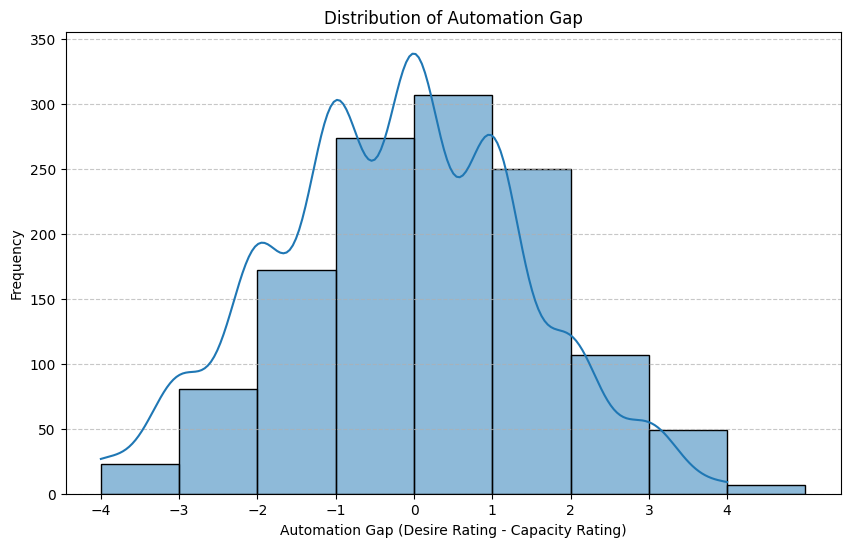

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_final['Automation_Gap'], bins=range(df_final['Automation_Gap'].min(), df_final['Automation_Gap'].max() + 2), kde=True)
plt.title('Distribution of Automation Gap')
plt.xlabel('Automation Gap (Desire Rating - Capacity Rating)')
plt.ylabel('Frequency')
plt.xticks(range(df_final['Automation_Gap'].min(), df_final['Automation_Gap'].max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Trực quan hóa dữ liệu (Data Visualizations)**
Đây là phần lõi của đồ án, hãy sắp xếp biểu đồ theo mạch truyện đã vạch ra:
1. **Mở bài:** Dùng `Bar Chart` hoặc `Donut Chart` biểu diễn tỷ lệ tần suất sử dụng LLM hàng ngày/tuần của các nhóm ngành nghề nhỏ trong CS.

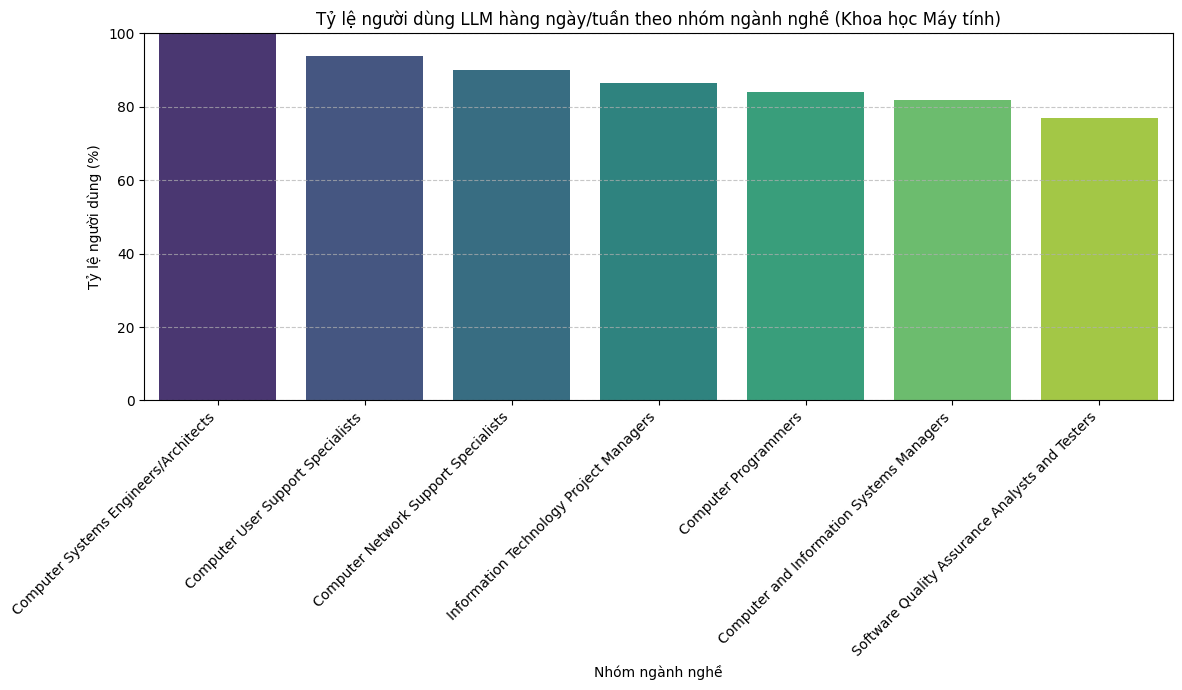

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define LLM usage type columns
llm_usage_types = [
    'LLM Usage by Type - Information Access',
    'LLM Usage by Type - Edit',
    'LLM Usage by Type - Idea Generation',
    'LLM Usage by Type - Communication',
    'LLM Usage by Type - Analysis',
    'LLM Usage by Type - Decision',
    'LLM Usage by Type - Coding',
    'LLM Usage by Type - System Design',
    'LLM Usage by Type - Data Processing'
]

# Select relevant columns and drop duplicates to count unique users
# We use User ID_x for unique individuals and Occupation (O*NET-SOC Title)_worker_meta for their occupation
df_users_llm = df_final[['User ID_x', 'Occupation (O*NET-SOC Title)_worker_meta'] + llm_usage_types].drop_duplicates(subset=['User ID_x'])

# Determine if a user uses any LLM type daily (score = 3) or weekly (score = 2)
# The apply function checks if any of the LLM usage columns for a given user row has a value of 2 or 3.
df_users_llm['uses_llm_daily_weekly'] = df_users_llm[llm_usage_types].apply(lambda row: any(x in [2, 3] for x in row), axis=1)

# Calculate the percentage of users within each occupation who use LLM daily/weekly
# value_counts(normalize=True) gives proportions, then unstack makes 'True' and 'False' columns
daily_weekly_llm_pct_unstacked = df_users_llm.groupby('Occupation (O*NET-SOC Title)_worker_meta')['uses_llm_daily_weekly'].value_counts(normalize=True).unstack(fill_value=0)

# Extract the percentage for 'True' (users who use LLM daily/weekly).
# If there are no True values in an occupation, it will correctly be 0 due to fill_value=0.
if True in daily_weekly_llm_pct_unstacked.columns:
    daily_weekly_llm_percentage = daily_weekly_llm_pct_unstacked[True] * 100
else:
    # If no users across ALL occupations use LLM daily/weekly, create a Series of zeros
    daily_weekly_llm_percentage = pd.Series(0.0, index=df_users_llm['Occupation (O*NET-SOC Title)_worker_meta'].unique())

# Sort the results for better visualization
daily_weekly_llm_percentage = daily_weekly_llm_percentage.sort_values(ascending=False)

# Create the Bar Chart
plt.figure(figsize=(12, 7))
sns.barplot(x=daily_weekly_llm_percentage.index, y=daily_weekly_llm_percentage.values, palette='viridis')
plt.title('Tỷ lệ người dùng LLM hàng ngày/tuần theo nhóm ngành nghề (Khoa học Máy tính)')
plt.xlabel('Nhóm ngành nghề')
plt.ylabel('Tỷ lệ người dùng (%)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.ylim(0, 100) # Ensure y-axis is from 0 to 100 for percentages
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a subtle grid
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

**Nhận xét:**
Biểu đồ cột hiển thị tỷ lệ người dùng LLM hàng ngày/tuần theo nhóm ngành nghề trong Khoa học Máy tính.

Có thể thấy rằng:
- `Computer Systems Engineers`/`Architects` có tỷ lệ sử dụng LLM hàng ngày/tuần cao nhất, **gần 100%**.
- `Computer User Support Specialists` cũng có tỷ lệ rất cao, **trên 90%**.
- Nhóm `Software Quality Assurance Analysts` and `Testers` có tỷ lệ thấp nhất nhưng vẫn ở mức đáng kể, `khoảng 77%`.

Điều này cho thấy LLM đang được sử dụng rộng rãi, đặc biệt là trong một số vai trò kỹ thuật cụ thể trong lĩnh vực Khoa học Máy tính.

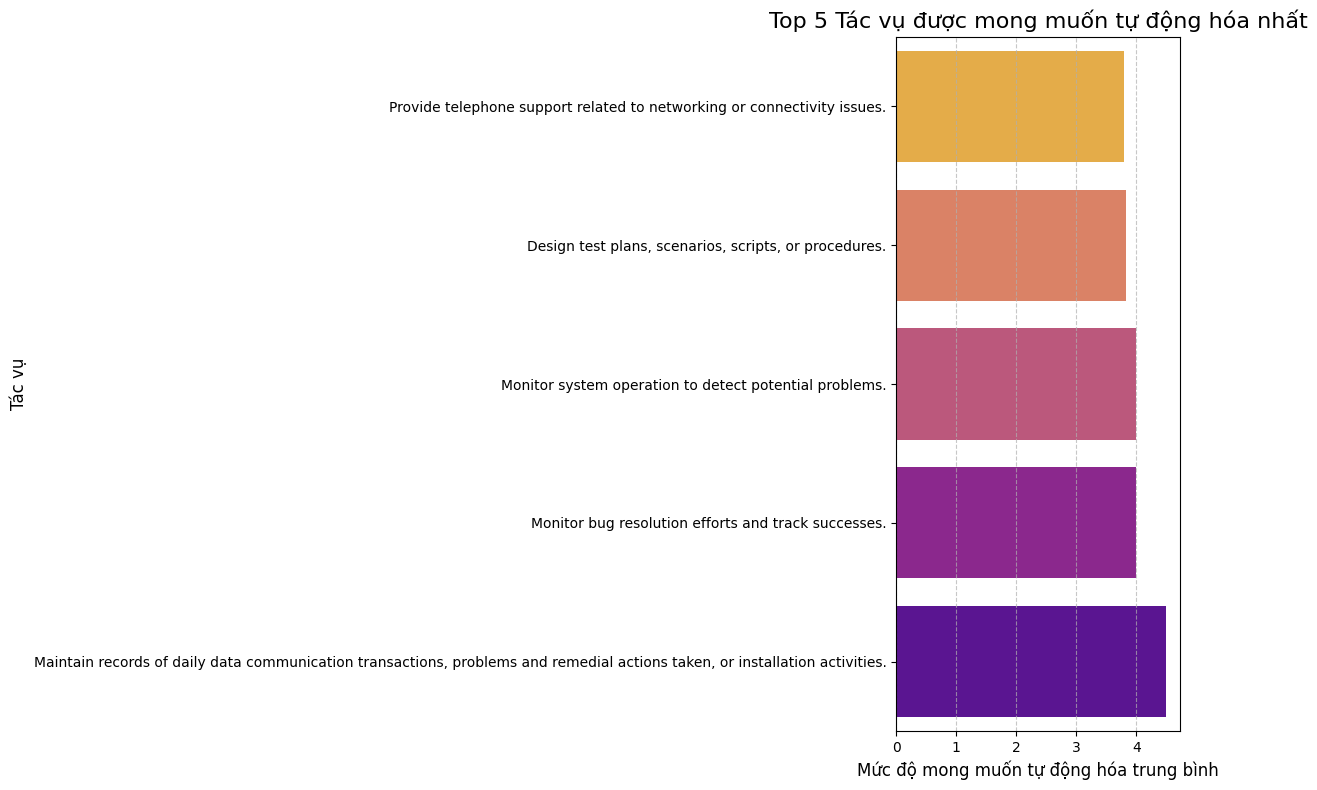

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the average Automation Desire Rating for each task
task_automation_desire = df_final.groupby('Task')['Automation Desire Rating'].mean().sort_values(ascending=False)

# Get the top 5 tasks with the highest automation desire
top_5_automation_tasks = task_automation_desire.head(5)

# Create the horizontal bar chart
plt.figure(figsize=(12, 8)) # Adjusted figure size for horizontal bars
sns.barplot(x=top_5_automation_tasks.values, y=top_5_automation_tasks.index, palette='plasma') # Swapped x and y
plt.title('Top 5 Tác vụ được mong muốn tự động hóa nhất', fontsize=16)
plt.xlabel('Mức độ mong muốn tự động hóa trung bình', fontsize=12)
plt.ylabel('Tác vụ', fontsize=12)
plt.yticks(fontsize=10) # No rotation needed for y-axis labels
plt.grid(axis='x', linestyle='--', alpha=0.7) # Grid on x-axis for horizontal bars
plt.gca().invert_yaxis() # Invert y-axis to have the highest value at the top
plt.tight_layout()
plt.show()

**Nhận xét:**
- Maintain records of daily data communication transactions, problems and remedial actions taken, or installation activities. (Duy trì hồ sơ giao dịch truyền dữ liệu hàng ngày, sự cố và các hành động khắc phục, hoặc các hoạt động cài đặt.) - Mức độ mong muốn trung bình: 4.5

- Monitor bug resolution efforts and track successes. (Theo dõi nỗ lực khắc phục lỗi và theo dõi thành công.) - Mức độ mong muốn trung bình: 4.0

- Monitor system operation to detect potential problems. (Theo dõi hoạt động hệ thống để phát hiện các vấn đề tiềm ẩn.) - Mức độ mong muốn trung bình: 4.0

- Design test plans, scenarios, scripts, or procedures. (Thiết kế kế hoạch kiểm thử, kịch bản, script hoặc quy trình.) - Mức độ mong muốn trung bình: 3.9

- Provide telephone support related to networking or connectivity issues. (Cung cấp hỗ trợ điện thoại liên quan đến các vấn đề mạng hoặc kết nối.) - Mức độ mong muốn trung bình: 3.8

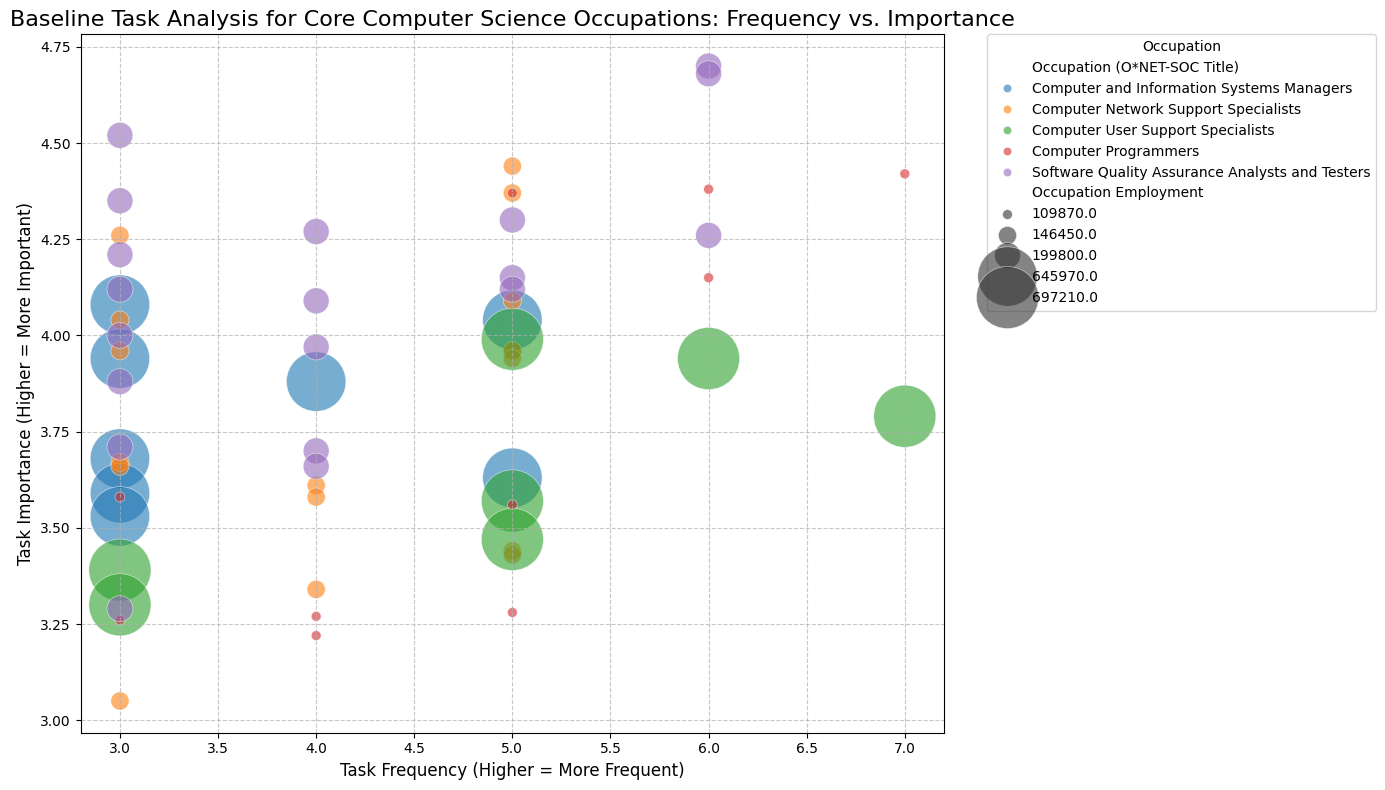


--- Identifying Pain-Point Tasks (High Freq, High Imp, High Emp, Routine Skill) ---

Top Core CS Tasks (High Frequency, High Importance, High Employment, with Routine Skills):
                                                                                                                                                               Task                     Occupation (O*NET-SOC Title)  Frequency  Importance  Occupation Employment                                                                                             Skill_List
549                                                              Identify, analyze, and document problems with program function, output, online screen, or content.  Software Quality Assurance Analysts and Testers        6.0        4.70               199800.0             [Analyzing Data or Information, Working with Computers, Documenting/Recording Information]
550                                                              Document software defects, using a

In [26]:
import ast # To convert string representation of list to actual list

# 1. Identify Computer Science occupations from the df_final
cs_keywords = ['Software', 'Computer', 'Data', 'Programmer', 'Developer']
cs_occupations = df_final[df_final['Occupation (O*NET-SOC Title)_worker_meta'].str.contains('|'.join(cs_keywords), na=False)]['Occupation (O*NET-SOC Title)_worker_meta'].unique()

# 2. Filter the original task_statements for Core tasks within these identified CS occupations
# Note: task_statements is already filtered for CS occupations from a previous step, but we need to ensure the correct column is used
core_cs_tasks_df = task_statements[
    task_statements['Occupation (O*NET-SOC Title)'].isin(cs_occupations) &
    (task_statements['Task Type'] == 'Core')
].copy()

# 3. Ensure numerical columns are correctly typed and handle potential NaNs
core_cs_tasks_df.dropna(subset=['Frequency', 'Importance', 'Occupation Employment'], inplace=True)
core_cs_tasks_df['Frequency'] = pd.to_numeric(core_cs_tasks_df['Frequency'])
core_cs_tasks_df['Importance'] = pd.to_numeric(core_cs_tasks_df['Importance'])
core_cs_tasks_df['Occupation Employment'] = pd.to_numeric(core_cs_tasks_df['Occupation Employment'])

# Convert 'Skill (O*NET Work Activity)' from string representation of list to actual list
def parse_skill_list(skill_str):
    try:
        return ast.literal_eval(skill_str)
    except (ValueError, SyntaxError):
        return [] # Return empty list if parsing fails

core_cs_tasks_df['Skill_List'] = core_cs_tasks_df['Skill (O*NET Work Activity)'].apply(parse_skill_list)

# 4. Create the Scatter Plot
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=core_cs_tasks_df,
    x='Frequency',
    y='Importance',
    size='Occupation Employment', # Map to bubble size
    hue='Occupation (O*NET-SOC Title)', # Color by occupation
    sizes=(50, 2000), # Adjust min and max size of bubbles for better visualization
    alpha=0.6,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Baseline Task Analysis for Core Computer Science Occupations: Frequency vs. Importance', fontsize=16)
plt.xlabel('Task Frequency (Higher = More Frequent)', fontsize=12)
plt.ylabel('Task Importance (Higher = More Important)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Occupation', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, ncol=1)
plt.tight_layout()
plt.show()

# 5. Identify pain-point tasks based on combined metrics and 'routine' skills
print("\n--- Identifying Pain-Point Tasks (High Freq, High Imp, High Emp, Routine Skill) ---")

# Define 'routine' skills keywords. These are common O*NET work activities that can be repetitive or process-oriented.
routine_skill_keywords = [
    'Processing Information',
    'Documenting/Recording Information',
    'Working with Computers', # Can be routine for some tasks
    'Updating and Using Relevant Knowledge' # Can involve routine updates
]

def has_routine_skill(skill_list, keywords):
    return any(any(keyword in s for s in skill_list) for keyword in keywords)

core_cs_tasks_df['Has_Routine_Skill'] = core_cs_tasks_df['Skill_List'].apply(lambda x: has_routine_skill(x, routine_skill_keywords))

# Calculate medians for filtering 'high' values
freq_median = core_cs_tasks_df['Frequency'].median()
imp_median = core_cs_tasks_df['Importance'].median()
emp_median_tasks = core_cs_tasks_df['Occupation Employment'].median()

# Filter for top tasks (high frequency, importance, employment) that also have routine skills
top_pain_point_tasks = core_cs_tasks_df[
    (core_cs_tasks_df['Frequency'] >= freq_median) &
    (core_cs_tasks_df['Importance'] >= imp_median) &
    (core_cs_tasks_df['Occupation Employment'] >= emp_median_tasks) &
    (core_cs_tasks_df['Has_Routine_Skill'] == True)
].sort_values(by=['Frequency', 'Importance', 'Occupation Employment'], ascending=[False, False, False])

print("\nTop Core CS Tasks (High Frequency, High Importance, High Employment, with Routine Skills):")
if not top_pain_point_tasks.empty:
    print(top_pain_point_tasks[['Task', 'Occupation (O*NET-SOC Title)', 'Frequency', 'Importance', 'Occupation Employment', 'Skill_List']].head(10).to_string())
else:
    print("No tasks found matching the criteria for high frequency, importance, employment, and routine skills.")

# Optionally, calculate a composite 'Pain_Point_Score' for more granular ranking
# Normalize employment for fair weighting
core_cs_tasks_df['Normalized_Employment'] = core_cs_tasks_df['Occupation Employment'] / core_cs_tasks_df['Occupation Employment'].max()
core_cs_tasks_df['Pain_Point_Score'] = core_cs_tasks_df['Frequency'] * core_cs_tasks_df['Importance'] * core_cs_tasks_df['Normalized_Employment']

# Increase score for tasks with routine skills
core_cs_tasks_df.loc[core_cs_tasks_df['Has_Routine_Skill'] == True, 'Pain_Point_Score'] *= 2

most_significant_pain_point_task = core_cs_tasks_df.sort_values(by='Pain_Point_Score', ascending=False).head(1)

if not most_significant_pain_point_task.empty:
    print("\n--- Most Significant Pain-Point Task (Highest Composite Score) ---")
    print(most_significant_pain_point_task[['Task', 'Occupation (O*NET-SOC Title)', 'Frequency', 'Importance', 'Occupation Employment', 'Skill_List', 'Pain_Point_Score']].to_string(index=False))
else:
    print("No task found with a significant pain-point score.")

Biểu đồ phân tán này thể hiện mối quan hệ giữa **tần suất thực hiện** một tác vụ (trục X) và **tầm quan trọng** của tác vụ đó (trục Y) trong các ngành nghề Khoa học Máy tính cốt lõi. Kích thước của mỗi điểm (bubble) biểu thị **số lượng việc làm** trong ngành nghề đó, trong khi màu sắc phân biệt các nhóm ngành nghề.

**Những điểm nổi bật từ biểu đồ và phân tích kèm theo:**

1.  **Phân bố chung:** Có nhiều tác vụ tập trung ở khu vực có tần suất và tầm quan trọng cao, cho thấy nhiều công việc cốt lõi trong ngành CS vừa được thực hiện thường xuyên vừa có vai trò quan trọng.
2.  **Phân biệt theo ngành nghề:** Mỗi màu sắc đại diện cho một nhóm ngành nghề cụ thể (ví dụ: Kỹ sư/Kiến trúc sư Hệ thống Máy tính, Chuyên gia Hỗ trợ Người dùng Máy tính, Lập trình viên Máy tính, v.v.). Sự phân bố của các điểm cho từng màu giúp chúng ta hiểu rằng các nhóm ngành nghề khác nhau có các tác vụ đặc trưng với tần suất và tầm quan trọng khác nhau.
3.  **Điểm đau (Pain-point tasks):** Phân tích đã xác định được những tác vụ có tần suất cao, tầm quan trọng cao, số lượng việc làm lớn và liên quan đến các kỹ năng 'thường nhật' (routine skills). Tác vụ nổi bật nhất là:
    *   **"Read technical manuals, confer with users, or conduct computer diagnostics to investigate and resolve problems or to provide technical assistance and support."** (Đọc tài liệu kỹ thuật, trao đổi với người dùng, hoặc thực hiện chẩn đoán máy tính để điều tra và giải quyết vấn đề hoặc cung cấp hỗ trợ kỹ thuật và hỗ trợ.)
    *   Tác vụ này thuộc nhóm **Computer User Support Specialists**, có tần suất cao (6.0), tầm quan trọng đáng kể (3.94) và số lượng việc làm rất lớn (697,210), đồng thời liên quan đến các kỹ năng thường nhật như 'Tìm kiếm thông tin', 'Làm việc với máy tính', 'Giao tiếp'. Điều này cho thấy đây là một 'điểm đau' đáng kể, có tiềm năng lớn để cải thiện hoặc tự động hóa.

**Ý nghĩa:** Biểu đồ và phân tích này giúp nhận diện các tác vụ trọng yếu và tiềm năng cho việc tối ưu hóa quy trình hoặc áp dụng các giải pháp tự động hóa, đặc biệt là những tác vụ đang gây ra 'điểm đau' cho một lượng lớn người lao động trong ngành Khoa học Máy tính.

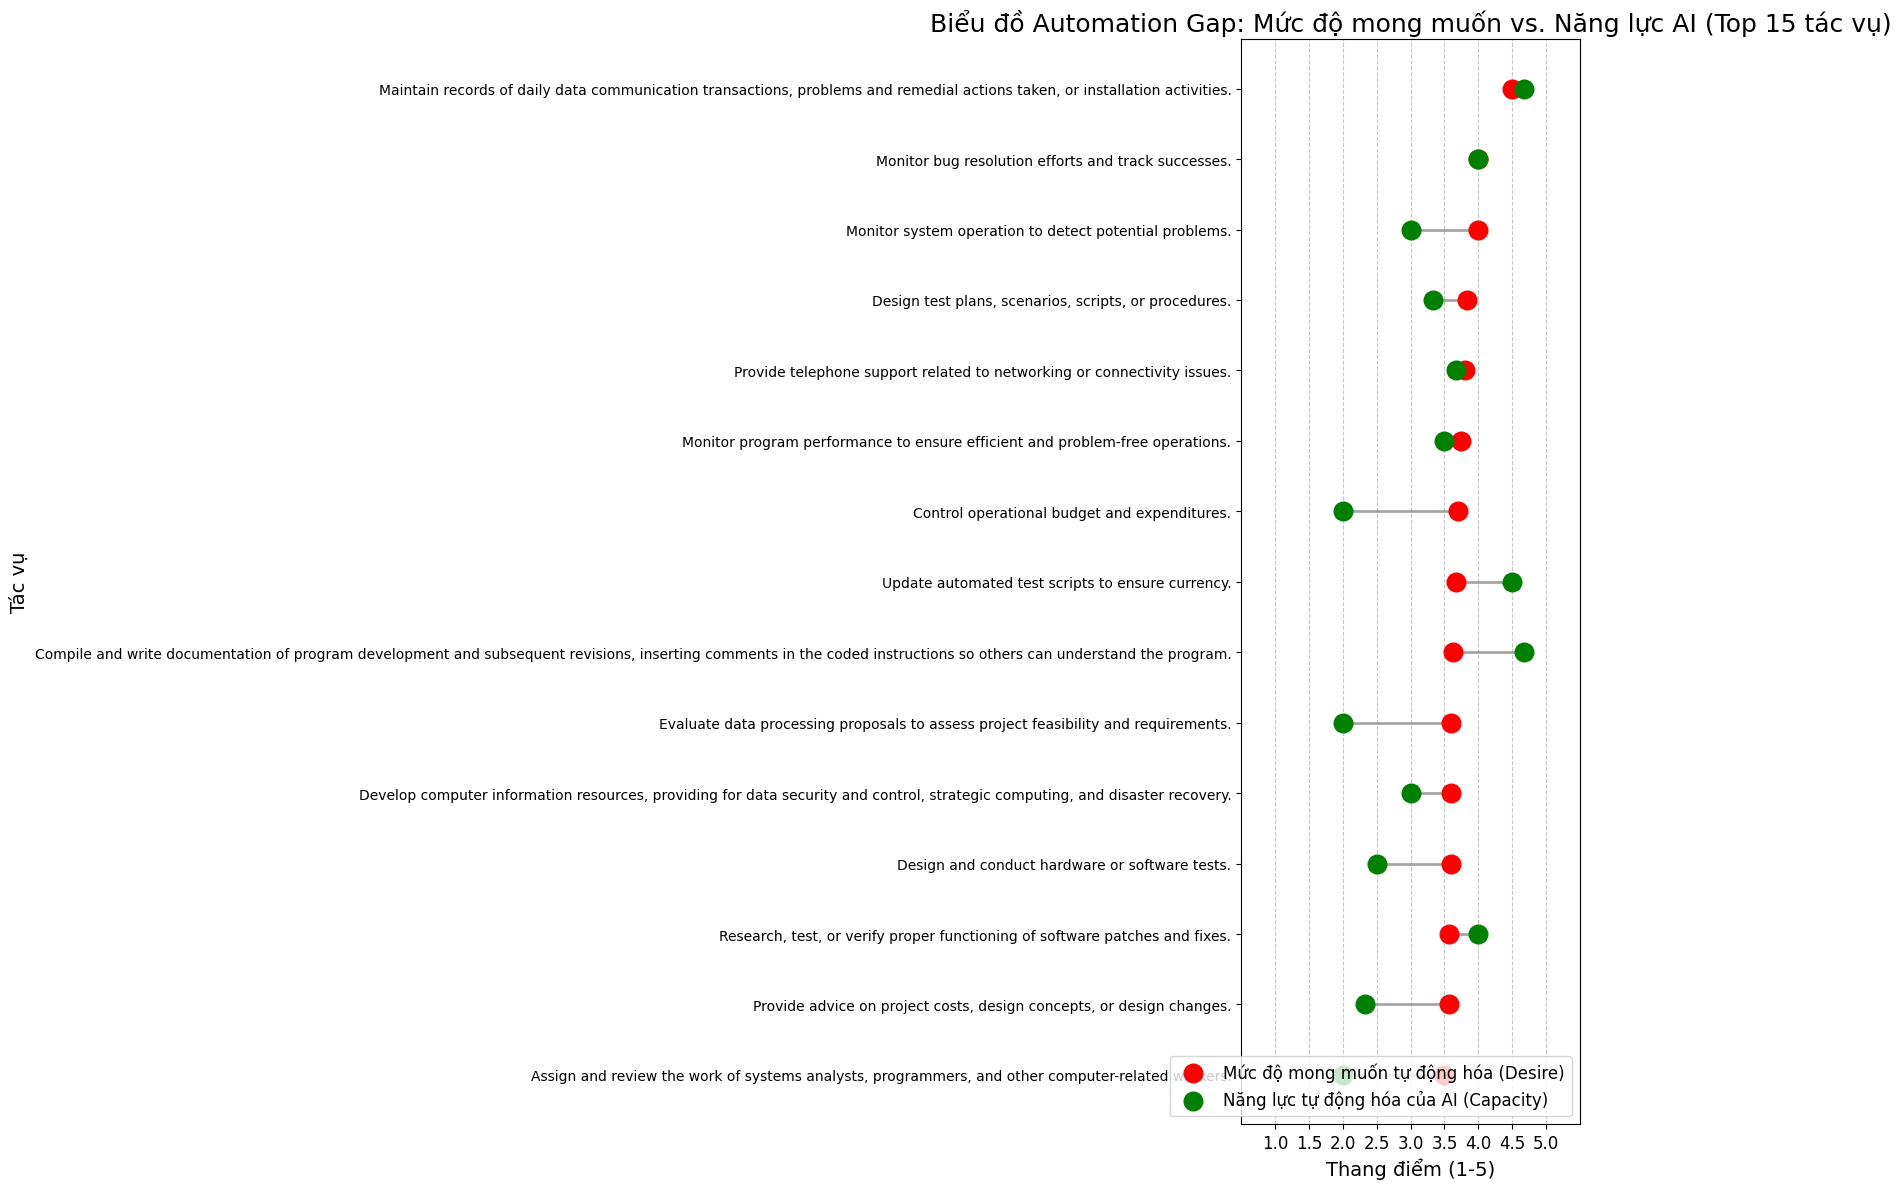

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Calculate the average Automation Desire Rating and Automation Capacity Rating for each task
task_automation_data = df_final.groupby('Task')[['Automation Desire Rating', 'Automation Capacity Rating']].mean()

# 2. Select the Top 15 tasks based on average Automation Desire Rating
# Sort in descending order so the highest desire tasks appear at the top after inverting the y-axis
top_15_tasks = task_automation_data.sort_values(by='Automation Desire Rating', ascending=False).head(15)

# Prepare data for plotting
tasks = top_15_tasks.index.tolist()
desire_ratings = top_15_tasks['Automation Desire Rating'].values
capacity_ratings = top_15_tasks['Automation Capacity Rating'].values
y_positions = np.arange(len(tasks)) # Numerical positions for y-axis

# Create the Dumbbell Plot
plt.figure(figsize=(16, 12)) # Further increased figure size for better readability

# Draw the connecting lines for each task
for i in range(len(tasks)):
    plt.hlines(y=y_positions[i],
               xmin=min(capacity_ratings[i], desire_ratings[i]),
               xmax=max(capacity_ratings[i], desire_ratings[i]),
               color='gray',
               alpha=0.7,
               linewidth=2)

# Plot the 'Desire' points (Red)
plt.scatter(desire_ratings, y_positions, color='red', s=180, label='Mức độ mong muốn tự động hóa (Desire)', zorder=2)

# Plot the 'Capacity' points (Green)
plt.scatter(capacity_ratings, y_positions, color='green', s=180, label='Năng lực tự động hóa của AI (Capacity)', zorder=2)

# Add labels and title
plt.title('Biểu đồ Automation Gap: Mức độ mong muốn vs. Năng lực AI (Top 15 tác vụ)', fontsize=18)
plt.xlabel('Thang điểm (1-5)', fontsize=14)
plt.ylabel('Tác vụ', fontsize=14)
plt.yticks(y_positions, tasks, fontsize=10) # Slightly reduced y-tick font size
plt.xticks(np.arange(1, 5.1, 0.5), fontsize=12) # Set x-ticks from 1 to 5 with 0.5 intervals
plt.xlim(0.5, 5.5) # Set x-axis limits to clearly show 1-5 scale
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(loc='lower right', fontsize=12)
plt.gca().invert_yaxis() # Invert y-axis to have the highest desire task at the top
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

**Nhận xét từ biểu đồ:**
1. **"Gap" lớn, Mong muốn > Năng lực AI (Chấm Đỏ xa Chấm Xanh về phía phải):** Các tác vụ có khoảng cách tự động hóa lớn nhất(4.5), nơi người lao động rất muốn AI hỗ trợ nhưng năng lực AI hiện tại được đánh giá thấp hơn (3.5), bao gồm:

- **Maintain records of daily data communication transactions, problems and remedial actions taken, or installation activities.** (Duy trì hồ sơ giao dịch truyền dữ liệu hàng ngày, sự cố và các hành động khắc phục, hoặc các hoạt động cài đặt.) - Đây là tác vụ có mong muốn tự động hóa cao nhất nhưng năng lực AI lại thấp hơn đáng kể. Khoảng cách này cho thấy đây là "điểm đau" lớn cần ưu tiên nghiên cứu giải pháp AI.
- **Monitor bug resolution efforts and track successes.** (Theo dõi nỗ lực khắc phục lỗi và theo dõi thành công.)
- **Monitor system operation to detect potential problems.** (Theo dõi hoạt động hệ thống để phát hiện các vấn đề tiềm ẩn.)
- **Design test plans, scenarios, scripts, or procedures.** (Thiết kế kế hoạch kiểm thử, kịch bản, script hoặc quy trình.)

2. **"Gap" âm, Năng lực AI > Mong muốn (Chấm Xanh xa Chấm Đỏ về phía phải):** Một số tác vụ có vẻ như AI có khả năng thực hiện tốt hơn so với mong muốn của người lao động. Ví dụ:

- **Control operational budget and expenditures.** (Kiểm soát ngân sách hoạt động và chi tiêu.) - AI được đánh giá có năng lực cao (4.5) nhưng mong muốn của người lao động lại thấp hơn(2.0).
- **Assign and review the work of systems analysts, programmers, and other computer related workers.** (Phân công và xem xét công việc của các nhà phân tích hệ thống, lập trình viên và các nhân viên liên quan đến máy tính khác.)
- **Research, test, or verify proper functioning of software patches and fixes.** (Nghiên cứu, kiểm tra hoặc xác minh chức năng phù hợp của các bản vá và sửa lỗi phần mềm.)

**Giải thích:** Khoảng cách lớn nơi mong muốn vượt quá năng lực (chấm Đỏ nằm xa bên phải chấm Xanh) chỉ ra những lĩnh vực mà việc đầu tư vào phát triển AI có thể mang lại lợi ích lớn nhất, giải quyết được nhu cầu cấp thiết của người lao động. Ngược lại, khi năng lực AI vượt trội hơn mong muốn (chấm Xanh xa bên phải chấm Đỏ), điều này có thể gợi ý rằng cần có các chiến dịch truyền thông để nâng cao nhận thức về tiềm năng của AI, hoặc người lao động đang hài lòng với cách làm hiện tại.

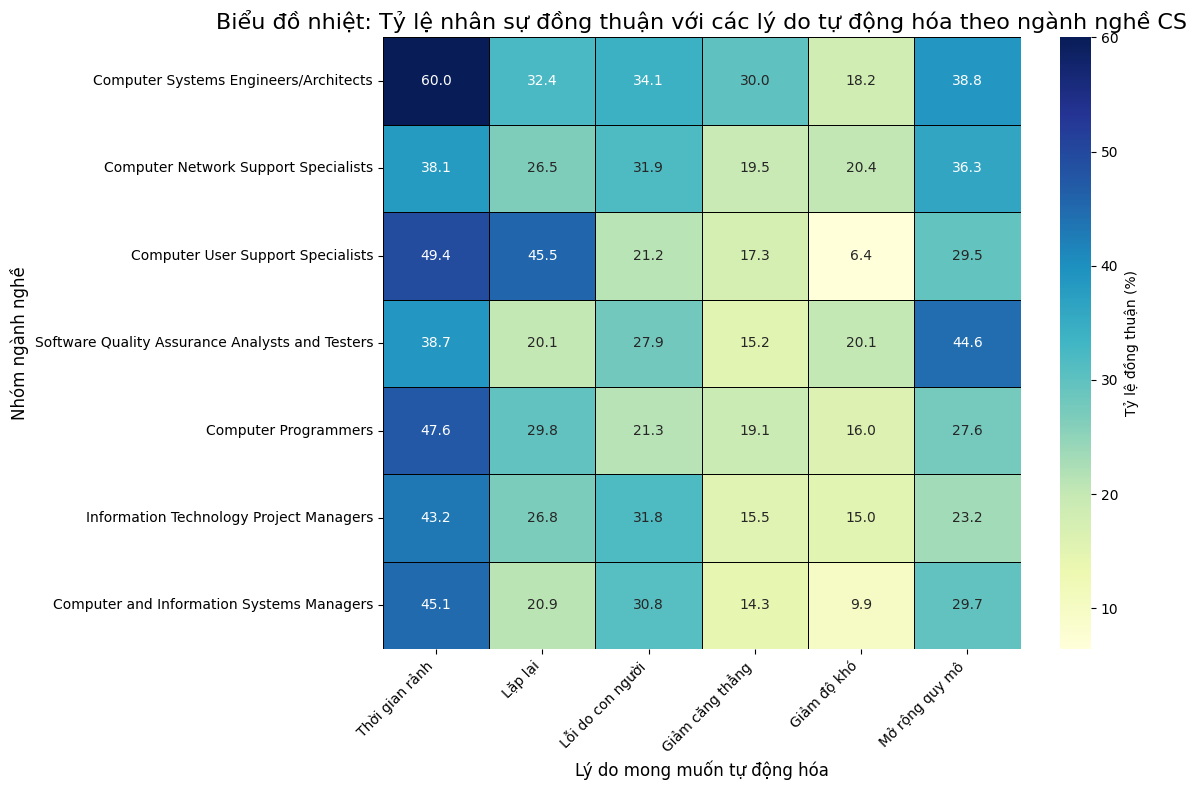

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the columns for automation desire reasons
automation_desire_reason_cols = [
    'Reasons for Automation Desire - Free Time',
    'Reasons for Automation Desire - Repetitive',
    'Reasons for Automation Desire - Human Error',
    'Reasons for Automation Desire - Stress',
    'Reasons for Automation Desire - Difficulty',
    'Reasons for Automation Desire - Scale'
]

# Map original column names to Vietnamese for better plot labels
reason_labels = {
    'Reasons for Automation Desire - Free Time': 'Thời gian rảnh',
    'Reasons for Automation Desire - Repetitive': 'Lặp lại',
    'Reasons for Automation Desire - Human Error': 'Lỗi do con người',
    'Reasons for Automation Desire - Stress': 'Giảm căng thẳng',
    'Reasons for Automation Desire - Difficulty': 'Giảm độ khó',
    'Reasons for Automation Desire - Scale': 'Mở rộng quy mô'
}

# Prepare the data for the heatmap
# Group by occupation and calculate the mean of each reason (since they are 0/1)
heatmap_data = df_final.groupby('Occupation (O*NET-SOC Title)_worker_meta')[automation_desire_reason_cols].mean() * 100

# Rename columns for better readability in the plot
heatmap_data = heatmap_data.rename(columns=reason_labels)

# Sort by total desire (optional, but can improve visualization)
heatmap_data['Total_Desire'] = heatmap_data.sum(axis=1)
heatmap_data = heatmap_data.sort_values(by='Total_Desire', ascending=False).drop(columns=['Total_Desire'])

# Create the heatmap
plt.figure(figsize=(12, 8)) # Adjust figure size for better readability
sns.heatmap(
    heatmap_data,
    annot=True,      # Show the data values on the heatmap
    fmt=".1f",       # Format annotations to one decimal place
    cmap="YlGnBu",   # Color map: Yellow-Green-Blue, darker means higher value
    linewidths=.5,   # Add lines between cells
    linecolor='black', # Color of the lines
    cbar_kws={'label': 'Tỷ lệ đồng thuận (%)'} # Color bar label
)

plt.title('Biểu đồ nhiệt: Tỷ lệ nhân sự đồng thuận với các lý do tự động hóa theo ngành nghề CS', fontsize=16)
plt.xlabel('Lý do mong muốn tự động hóa', fontsize=12)
plt.ylabel('Nhóm ngành nghề', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate x-axis labels
plt.yticks(fontsize=10)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

**Nhận xét:**
1. **"Thời gian rảnh" và "Lặp lại" là động lực chính:**

Hai lý do này có tỷ lệ đồng thuận cao nhất trên toàn bộ các ngành nghề. Đặc biệt, **Computer Systems Engineers/Architects** dẫn đầu với `60.0%` đồng thuận cho "Thời gian rảnh" và **Computer User Support Specialists** có tỷ lệ cao nhất cho "Lặp lại" với `45.5%.`
Điều này khẳng định lại rằng việc giải phóng thời gian và giảm bớt các tác vụ lặp đi lặp lại là những lợi ích hàng đầu mà nhân sự mong đợi từ tự động hóa.

2. **"Lỗi do con người" cũng là một yếu tố quan trọng:**

Đây là lý do phổ biến thứ ba, với tỷ lệ đồng thuận khá đồng đều, dao động khoảng `20-34%` trên các nhóm ngành nghề. **Computer Systems Engineers/Architects** (`34.1%`) và **Information Technology Project Managers** (`31.8%`) là những nhóm có tỷ lệ cao hơn một chút, cho thấy họ nhận thức rõ về tầm quan trọng của việc giảm thiểu sai sót trong công việc của mình.

3. **Các lý do khác ("Giảm căng thẳng", "Giảm độ khó", "Mở rộng quy mô") ít được ưu tiên hơn:**

Các lý do như "Giảm căng thẳng", "Giảm độ khó" và "Mở rộng quy mô" thường có tỷ lệ đồng thuận thấp hơn, thường `dưới 20%`, ngoại trừ một vài trường hợp. Ví dụ, **Software Quality Assurance Analysts and Testers** có tỷ lệ 4`4.6%` cho lý do "Mở rộng quy mô", có thể do tính chất công việc của họ liên quan đến việc kiểm thử trên quy mô lớn, và tự động hóa có thể giúp họ xử lý khối lượng công việc này hiệu quả hơn.

4. **Sự khác biệt giữa các nhóm ngành nghề:**

- **Computer Systems Engineers/Architects:** Có tỷ lệ đồng thuận cao nhất cho "Thời gian rảnh" (`60.0%`) và cao cho "Mở rộng quy mô" (`38.8%`), "Lỗi do con người" (`34.1%`). Điều này cho thấy họ mong muốn tự động hóa để tối ưu hóa hiệu suất tổng thể và quản lý hệ thống phức tạp.
- **Computer User Support Specialists:** Nổi bật với lý do "Lặp lại" (`45.5%`), cho thấy nhiều tác vụ hỗ trợ người dùng có tính chất lặp lại và họ muốn tự động hóa để xử lý các yêu cầu này hiệu quả hơn.
- **Software Quality Assurance Analysts and Testers:** Ngoài "Mở rộng quy mô" đã đề cập, họ cũng có tỷ lệ khá cao cho "Thời gian rảnh" (`38.7%`), điều này hợp lý vì tự động hóa kiểm thử là một xu hướng lớn trong QA.

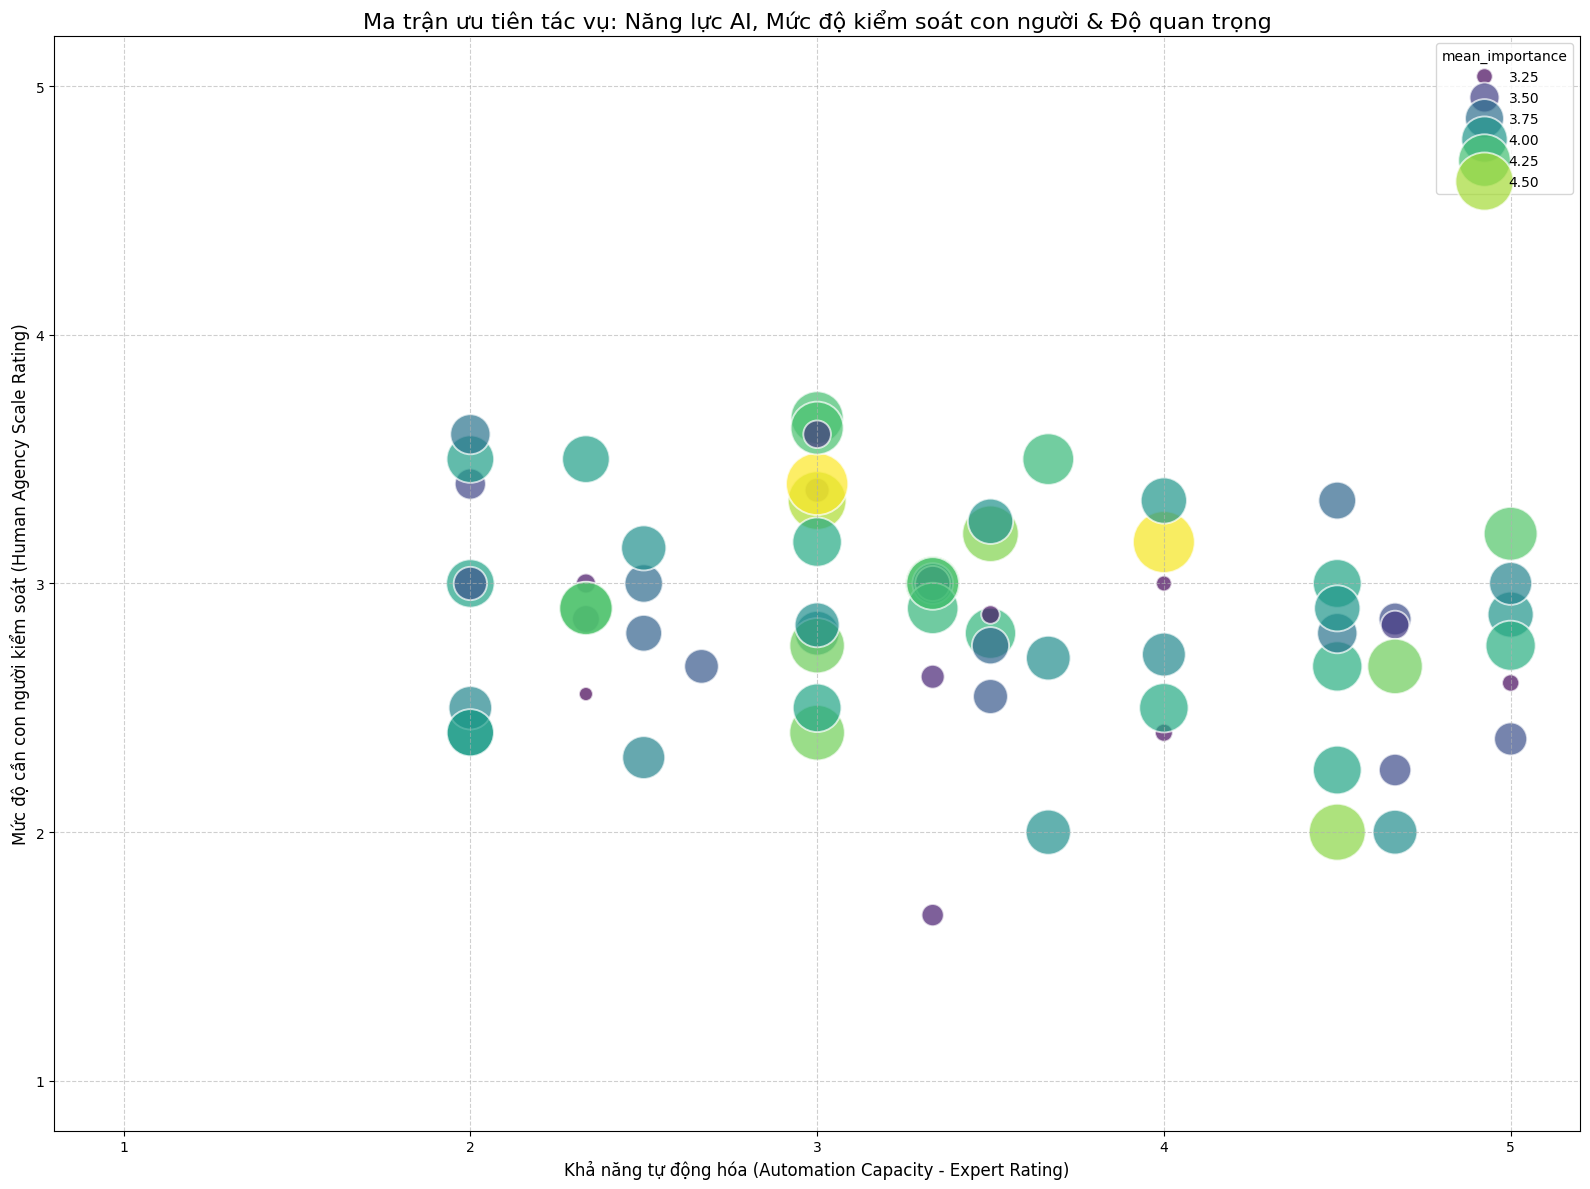

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- Bubble Chart: Priority Matrix ---

# Group df_final by Task ID and Task to get mean values for the required metrics
task_priority_data = df_final.groupby(['Task ID', 'Task']).agg(
    mean_automation_capacity=('Automation Capacity Rating', 'mean'),
    mean_human_agency=('Human Agency Scale Rating_x', 'mean'),
    mean_importance=('Importance', 'mean')
).reset_index()

# Ensure all columns are numeric, coercing errors will turn non-numeric into NaN
task_priority_data['mean_automation_capacity'] = pd.to_numeric(task_priority_data['mean_automation_capacity'], errors='coerce')
task_priority_data['mean_human_agency'] = pd.to_numeric(task_priority_data['mean_human_agency'], errors='coerce')
task_priority_data['mean_importance'] = pd.to_numeric(task_priority_data['mean_importance'], errors='coerce')

# Drop rows with NaN values that might result from coercion if values were truly unmappable
task_priority_data.dropna(subset=['mean_automation_capacity', 'mean_human_agency', 'mean_importance'], inplace=True)


plt.figure(figsize=(16, 12)) # Increased figure size for better layout

# Create the bubble chart
sns.scatterplot(
    data=task_priority_data,
    x='mean_automation_capacity',
    y='mean_human_agency',
    size='mean_importance', # Size of bubbles based on Importance
    hue='mean_importance', # Color of bubbles based on Importance
    sizes=(100, 2000), # Range of bubble sizes
    alpha=0.7,
    palette='viridis', # Colormap for importance
    legend='brief' # Changed from 'full' to 'brief' to simplify legend and reduce clutter
)

# Add labels and title
plt.title('Ma trận ưu tiên tác vụ: Năng lực AI, Mức độ kiểm soát con người & Độ quan trọng', fontsize=16)
plt.xlabel('Khả năng tự động hóa (Automation Capacity - Expert Rating)', fontsize=12)
plt.ylabel('Mức độ cần con người kiểm soát (Human Agency Scale Rating)', fontsize=12)

# Manually set x and y ticks and limits for better readability, assuming a 1-5 rating scale
plt.xticks(ticks=[1, 2, 3, 4, 5])
plt.yticks(ticks=[1, 2, 3, 4, 5])
plt.xlim(0.8, 5.2) # Extend slightly beyond 1-5 for visual padding
plt.ylim(0.8, 5.2) # Extend slightly beyond 1-5 for visual padding

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate some top tasks by importance or specific characteristics if desired
# For example, to annotate tasks with high importance:
# top_tasks_to_annotate = task_priority_data.nlargest(5, 'mean_importance')
# for i, row in top_tasks_to_annotate.iterrows():
#     plt.text(row['mean_automation_capacity'], row['mean_human_agency'], row['Task'], fontsize=9, ha='center', va='bottom')

plt.tight_layout() # Ensure called before plt.show()
plt.show()

**Nhận xét về Sơ đồ Sankey: Dòng chảy từ Kinh nghiệm đến Mong muốn Tự động hóa**

Sơ đồ Sankey này trình bày một cách trực quan về mối quan hệ đa tầng giữa kinh nghiệm làm việc, thái độ đối với ảnh hưởng của AI, tần suất sử dụng Mô hình ngôn ngữ lớn (LLM) và mức độ mong muốn tự động hóa trong các ngành nghề Khoa học Máy tính.

**Các điểm nổi bật từ biểu đồ:**

1.  **Dòng chảy từ Kinh nghiệm:**
    *   Có thể thấy các nhóm kinh nghiệm khác nhau (ví dụ: "Less than 1 year", "3-5 years", "More than 10 years") đều có sự phân bổ nhất định đến các cấp độ lo ngại về AI, mức độ sử dụng LLM và mong muốn tự động hóa.
    *   Cần quan sát kỹ để xem liệu có nhóm kinh nghiệm cụ thể nào có xu hướng lo ngại về AI nhiều hơn, sử dụng LLM thường xuyên hơn hoặc mong muốn tự động hóa cao hơn hay không.

2.  **Mối quan hệ giữa Kinh nghiệm và Thái độ lo ngại về AI (Experience -> AI Suffering Attitude):**
    *   Các luồng từ các cấp độ kinh nghiệm đến "Low Concern", "Neutral Concern", và "High Concern" sẽ cho thấy liệu kinh nghiệm có ảnh hưởng đến nhận thức về rủi ro hoặc tác động tiêu cực của AI hay không.
    *   Nếu có một luồng lớn từ "Less than 1 year" đến "High Concern", điều này có thể chỉ ra rằng những người mới vào nghề có xu hướng lo lắng nhiều hơn về AI, có thể do thiếu kinh nghiệm hoặc hiểu biết sâu sắc.

3.  **Mối quan hệ giữa Thái độ lo ngại về AI và Mức độ sử dụng LLM (AI Suffering Attitude -> LLM Usage):**
    *   Quan sát cách các cấp độ "Concern" (Low, Neutral, High) kết nối với các tần suất sử dụng LLM ("Never", "Monthly", "Weekly", "Daily").
    *   Chẳng hạn, nếu những người có "High Concern" vẫn sử dụng LLM "Daily" hoặc "Weekly", điều này có thể cho thấy LLM là công cụ không thể thiếu trong công việc của họ, bất chấp những lo ngại cá nhân.
    *   Ngược lại, nếu "Low Concern" dẫn đến việc sử dụng LLM thường xuyên hơn, điều này là hợp lý.

4.  **Mối quan hệ giữa Mức độ sử dụng LLM và Mong muốn tự động hóa (LLM Usage -> Automation Desire):**
    *   Đây là một mối liên kết quan trọng. Biểu đồ sẽ cho thấy liệu việc sử dụng LLM thường xuyên có đi đôi với mong muốn tự động hóa cao hay không.
    *   Nếu những người sử dụng LLM "Daily" hoặc "Weekly" có xu hướng có "High Desire" cho tự động hóa, điều này củng cố ý tưởng rằng LLM đang được xem như một công cụ hiệu quả để đạt được tự động hóa.
    *   Mặt khác, nếu việc sử dụng LLM "Never" hoặc "Rarely" vẫn dẫn đến "High Desire", điều này có thể gợi ý rằng mong muốn tự động hóa đến từ các yếu tố khác không liên quan trực tiếp đến việc sử dụng LLM hiện tại.

**Tổng kết:**
Biểu đồ Sankey cung cấp cái nhìn toàn diện về hành trình của người làm việc qua các giai đoạn từ kinh nghiệm, thái độ, hành vi sử dụng công nghệ đến mong muốn cuối cùng về tự động hóa. Nó giúp xác định các luồng chính và mối quan hệ giữa các yếu tố này, từ đó đưa ra các chiến lược hiệu quả hơn trong việc phát triển và triển khai AI/LLM trong môi trường làm việc.

In [36]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Define CS keywords to filter for Computer Science occupations
cs_keywords = ['Software', 'Computer', 'Data', 'Programmer', 'Developer']

# Create a base DataFrame for Sankey by filtering df_final for CS occupations
sankey_base_df = df_final[df_final['Occupation (O*NET-SOC Title)_worker_meta'].str.contains('|'.join(cs_keywords), na=False)].copy()

# Ensure the columns for Sankey are present and numeric.
# They are already processed in df_final from previous steps.
# Fill any remaining NaNs in these numeric columns in sankey_base_df *before* aggregation
# so that mode() doesn't return NaN, allowing categorization to work.
# Use a sentinel value (e.g., 0 for Experience/Attitude, -1 for LLM to be safe)
# that our categorization functions will interpret as 'Missing'.
sankey_base_df['Experience_Numeric'] = sankey_base_df['Experience_numeric'].fillna(0) # 0 will map to 'Missing Experience'
sankey_base_df['AI_Suffering_Attitude_Numeric'] = sankey_base_df['AI Suffering Attitude'].fillna(0) # 0 will map to 'Missing Concern Data'
sankey_base_df['LLM Usage by Type - Coding_Score'] = sankey_base_df['LLM Usage by Type - Coding'].fillna(-1) # -1 will map to 'Missing Usage Data'
sankey_base_df['LLM Usage by Type - System Design_Score'] = sankey_base_df['LLM Usage by Type - System Design'].fillna(-1) # -1 will map to 'Missing Usage Data'
sankey_base_df['Automation_Desire_Rating'] = sankey_base_df['Automation Desire Rating'].fillna(0) # 0 will map to 'Missing Desire'

# --- 1. Aggregate user-level data ---
sankey_data_agg = sankey_base_df.groupby('User ID_x').agg(
    Experience_Numeric=('Experience_Numeric', lambda x: x.mode()[0] if not x.mode().empty else 0), # If mode is empty, treat as missing
    AI_Suffering_Attitude_Numeric=('AI_Suffering_Attitude_Numeric', lambda x: x.mode()[0] if not x.mode().empty else 0),
    LLM_Usage_Coding_Score=('LLM Usage by Type - Coding_Score', 'mean'),
    LLM_Usage_System_Design_Score=('LLM Usage by Type - System Design_Score', 'mean'),
    Automation_Desire_Rating=('Automation_Desire_Rating', 'mean')
).reset_index()

# --- 2. Define Categorization Functions ---
def categorize_experience(exp_numeric):
    if pd.isna(exp_numeric) or exp_numeric == 0: return 'Missing Experience'
    if exp_numeric == 1: return 'Less than 1 year'
    if exp_numeric == 2: return '1-2 year'
    if exp_numeric == 3: return '3-5 years'
    if exp_numeric == 4: return '6-10 years'
    if exp_numeric == 5: return 'More than 10 years'
    return 'Other Experience' # Fallback for unexpected values

def categorize_ai_suffering(att_numeric):
    if pd.isna(att_numeric) or att_numeric == 0: return 'Missing Concern Data'
    if att_numeric <= 2: return 'Low Concern'
    if att_numeric == 3: return 'Neutral Concern'
    if att_numeric >= 4: return 'High Concern'
    return 'Other Concern' # Fallback

def categorize_llm_usage(coding_usage_score, system_design_usage_score):
    if pd.isna(coding_usage_score) and pd.isna(system_design_usage_score): return 'Missing Usage Data'

    usages = []
    if not pd.isna(coding_usage_score) and coding_usage_score != -1: usages.append(coding_usage_score)
    if not pd.isna(system_design_usage_score) and system_design_usage_score != -1: usages.append(system_design_usage_score)

    if not usages: return 'Missing Usage Data' # If both are missing or sentinel

    avg_usage_score = np.mean(usages)

    # Map the 0-3 score to descriptive labels
    if avg_usage_score < 0.5: return 'Never'
    if avg_usage_score < 1.5: return 'Monthly'
    if avg_usage_score < 2.5: return 'Weekly'
    if avg_usage_score >= 2.5: return 'Daily'
    return 'Other Usage' # Fallback

def categorize_automation_desire(desire_mean):
    if pd.isna(desire_mean) or desire_mean == 0: return 'Missing Desire'
    if desire_mean < 2.5: return 'Low Desire'
    if desire_mean < 3.5: return 'Neutral Desire'
    if desire_mean >= 3.5: return 'High Desire'
    return 'Other Desire' # Fallback

# --- 3. Apply Categorization to aggregated data ---
sankey_data_agg['Experience_Cat'] = sankey_data_agg['Experience_Numeric'].apply(categorize_experience)
sankey_data_agg['AI_Suffering_Cat'] = sankey_data_agg['AI_Suffering_Attitude_Numeric'].apply(categorize_ai_suffering)
sankey_data_agg['LLM_Usage_Cat'] = sankey_data_agg.apply(
    lambda row: categorize_llm_usage(row['LLM_Usage_Coding_Score'], row['LLM_Usage_System_Design_Score']), axis=1
)
sankey_data_agg['Automation_Desire_Cat'] = sankey_data_agg['Automation_Desire_Rating'].apply(categorize_automation_desire)

# --- 4. Prepare nodes and links for Sankey diagram ---
# No strict filtering for 'Unknown' anymore, as 'Missing' categories will be nodes.
sankey_data_filtered = sankey_data_agg.copy() # All rows now have a category or 'Missing' category

stages = ['Experience_Cat', 'AI_Suffering_Cat', 'LLM_Usage_Cat', 'Automation_Desire_Cat']

all_nodes = []
for stage in stages:
    all_nodes.extend(sankey_data_filtered[stage].unique())
all_nodes = list(pd.Series(all_nodes).unique())

node_to_id = {node: i for i, node in enumerate(all_nodes)}

links = []
for i in range(len(stages) - 1):
    source_stage = stages[i]
    target_stage = stages[i+1]

    flow_counts = sankey_data_filtered.groupby([source_stage, target_stage]).size().reset_index(name='count')

    for _, row in flow_counts.iterrows():
        source_label = row[source_stage]
        target_label = row[target_stage]
        count = row['count']

        links.append({
            'source': node_to_id[source_label],
            'target': node_to_id[target_label],
            'value': count
        })

links_df = pd.DataFrame(links)

# --- Add colors for nodes and links ---
# Define specific colors for nodes, including the new 'Missing' categories
node_colors = {
    'Less than 1 year': 'rgba(173,216,230,0.8)', # LightBlue
    '1-2 year': 'rgba(135,206,250,0.8)', # LightSkyBlue
    '3-5 years': 'rgba(100,149,237,0.8)', # CornflowerBlue
    '6-10 years': 'rgba(65,105,225,0.8)', # RoyalBlue
    'More than 10 years': 'rgba(0,0,139,0.8)', # DarkBlue
    'Missing Experience': 'rgba(200,200,200,0.8)', # Grey for missing

    'Low Concern': 'rgba(144,238,144,0.8)', # LightGreen
    'Neutral Concern': 'rgba(255,255,0,0.8)', # Yellow
    'High Concern': 'rgba(255,99,71,0.8)', # Tomato
    'Missing Concern Data': 'rgba(200,200,200,0.8)', # Grey for missing

    'Never': 'rgba(180,180,180,0.8)', # Grey
    'Monthly': 'rgba(255,215,0,0.8)', # Gold
    'Weekly': 'rgba(255,165,0,0.8)', # Orange
    'Daily': 'rgba(255,69,0,0.8)', # OrangeRed
    'Missing Usage Data': 'rgba(200,200,200,0.8)', # Grey for missing

    'Low Desire': 'rgba(255,235,205,0.8)', # BlanchedAlmond
    'Neutral Desire': 'rgba(255,192,203,0.8)', # Pink
    'High Desire': 'rgba(255,0,0,0.8)', # Red
    'Missing Desire': 'rgba(200,200,200,0.8)' # Grey for missing
}

# Create a list of node colors in the order of `all_nodes`
node_colors_list = [node_colors.get(node_label, 'grey') for node_label in all_nodes]

# Define link colors based on source node or target node for better visual flow
link_colors = []
for _, link_row in links_df.iterrows():
    source_node_id = link_row['source']
    source_node_label = all_nodes[source_node_id]
    color_rgb = node_colors.get(source_node_label, 'rgba(192,192,192,0.8)').replace('0.8', '0.4')
    link_colors.append(color_rgb)

# --- 5. Plot the Sankey diagram using Plotly ---
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_nodes,
        color=node_colors_list
    ),
    link=dict(
        source=links_df['source'],
        target=links_df['target'],
        value=links_df['value'],
        color=link_colors # Apply link colors
    )
)])

fig.update_layout(
    title_text="<b>Sơ đồ Sankey: Dòng chảy từ Kinh nghiệm đến Mong muốn Tự động hóa</b><br><i>Experience ➔ AI Suffering Attitude ➔ LLM Usage ➔ Automation Desire</i>",
    font_size=12,
    height=700
)
fig.show()

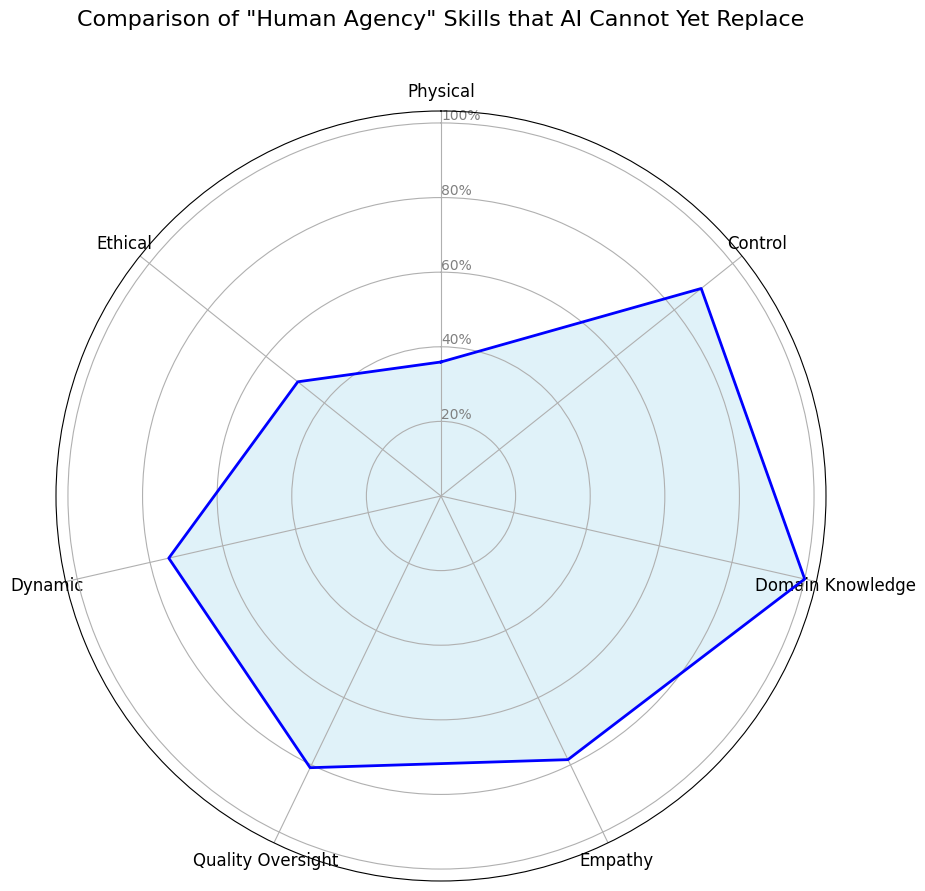

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Radar Chart: Human Agency Skills Comparison ---

# Define Human Agency reasons columns
human_agency_reason_cols = [
    'Reasons for Human Agency - Physical',
    'Reasons for Human Agency - Control',
    'Reasons for Human Agency - Domain Knowledge',
    'Reasons for Human Agency - Empathy',
    'Reasons for Human Agency - Quality Oversight',
    'Reasons for Human Agency - Dynamic',
    'Reasons for Human Agency - Ethical'
]

# Aggregate the sum of each reason across all relevant tasks/users
# Filter df_final for unique Task ID and User ID_x combinations to avoid overcounting
df_human_agency = df_final[['User ID_x', 'Task ID'] + human_agency_reason_cols].drop_duplicates(subset=['User ID_x', 'Task ID'])
aggr_human_agency = df_human_agency[human_agency_reason_cols].sum()

# Prepare data for Radar Chart
labels = [
    'Physical', 'Control', 'Domain Knowledge',
    'Empathy', 'Quality Oversight', 'Dynamic', 'Ethical'
]

# Values should be normalized or scaled for comparison on a radar chart
# Using max value to scale each reason to a 0-1 range for fair comparison
values = aggr_human_agency.values
max_value = values.max() # Get the highest count among the reasons
scaled_values = values / max_value

# Number of variables
num_vars = len(labels)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is circular, so we need to add the first value to the end of the list.
scaled_values = np.concatenate((scaled_values, [scaled_values[0]]))
angles = np.concatenate((angles, [angles[0]]))
labels_english = np.concatenate((labels, [labels[0]])) # Use original English labels

# Create the Radar Chart
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

ax.fill(angles, scaled_values, color='skyblue', alpha=0.25)
ax.plot(angles, scaled_values, color='blue', linewidth=2)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Draw axis lines for each angle and label.
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_english[:-1], fontsize=12) # Use English labels here

# Draw ylabels
ax.set_rlabel_position(0)
r_ticks = [0.2, 0.4, 0.6, 0.8, 1.0]
ax.set_yticks(r_ticks)
ax.set_yticklabels([f'{int(r*100)}%' for r in r_ticks], color='gray', size=10)
ax.tick_params(axis='y', colors='gray')

plt.title('Comparison of "Human Agency" Skills that AI Cannot Yet Replace', size=16, color='black', y=1.1) # Updated title
plt.show()

## Khuyến nghị cho ngành Khoa học Máy tính

Dựa trên các phân tích và biểu đồ đã thực hiện, đây là một số khuyến nghị cho ngành Khoa học Máy tính:

**1. Tập trung tự động hóa các 'điểm đau' và công việc lặp lại:**
   *   **Ưu tiên các tác vụ có nhu cầu tự động hóa cao và mang tính lặp lại:** Các tác vụ như `duy trì hồ sơ giao dịch dữ liệu`, `giám sát lỗi`, `theo dõi hoạt động hệ thống`, và `thiết kế kế hoạch kiểm thử` có mức độ mong muốn tự động hóa cao nhất. Đây là những điểm mà AI có thể mang lại hiệu quả tức thì, giúp giải phóng thời gian và giảm căng thẳng cho nhân sự.
   *   **Phát triển AI hỗ trợ các vai trò dịch vụ/hỗ trợ:** Tác vụ như `đọc tài liệu kỹ thuật, trao đổi với người dùng để giải quyết vấn đề hoặc hỗ trợ kỹ thuật` là 'điểm đau' lớn cho `Computer User Support Specialists` (tần suất cao, tầm quan trọng cao, số lượng việc làm lớn). Phát triển các công cụ AI/LLM chuyên biệt để tự động hóa hoặc hỗ trợ các tác vụ này có thể cải thiện đáng kể năng suất và sự hài lòng của nhân viên.

**2. Nâng cao năng lực AI cho các lĩnh vực có 'Khoảng cách tự động hóa' lớn:**
   *   **Đầu tư vào AI cho các tác vụ 'ghi chép và giám sát':** Các tác vụ như `Maintain records of daily data communication transactions` có mong muốn tự động hóa rất cao nhưng năng lực AI hiện tại được đánh giá thấp hơn. Đây là lĩnh vực cần nghiên cứu và phát triển AI chuyên sâu để thu hẹp 'khoảng cách' này.

**3. Tận dụng LLM một cách chiến lược theo kinh nghiệm:**
   *   **Hỗ trợ người mới vào nghề bằng LLM:** Người có ít kinh nghiệm (dưới 1 năm, 1-2 năm) sử dụng LLM rất nhiều cho `lập trình` và `truy cập thông tin`. Các tổ chức nên cung cấp tài nguyên và đào tạo để tối đa hóa lợi ích của LLM cho nhóm này, giúp họ nhanh chóng thích nghi và phát triển.
   *   **Phát triển LLM cho các tác vụ phân tích và ra quyết định phức tạp hơn:** Đối với nhân sự nhiều kinh nghiệm, việc sử dụng LLM cho các tác vụ `phân tích` và `ra quyết định` giảm đi. Cần nghiên cứu cách thức để LLM có thể hỗ trợ hiệu quả hơn cho các tác vụ này, nâng cao khả năng 'lý luận' và 'tổng hợp' của AI.

**4. Bảo vệ và phát triển các kỹ năng 'Human Agency' (khả năng kiểm soát của con người):**
   *   **Tăng cường vai trò con người trong 'Kiến thức chuyên môn' và 'Kiểm soát':** Biểu đồ Radar cho thấy `Domain Knowledge` (Kiến thức chuyên môn) và `Control` (Kiểm soát) là hai kỹ năng mà con người đóng vai trò chủ chốt và AI khó thay thế. Các chương trình đào tạo và phát triển nghề nghiệp nên tập trung vào việc củng cố những kỹ năng này, biến chúng thành lợi thế cạnh tranh của nhân sự trong kỷ nguyên AI.
   *   **Thiết kế hệ thống AI theo hướng cộng tác:** Thay vì thay thế, AI nên được thiết kế để hỗ trợ và tăng cường năng lực của con người, đặc biệt trong các lĩnh vực yêu cầu sự `đồng cảm`, `giám sát chất lượng` và `đạo đức`.

**5. Nâng cao nhận thức và giảm thiểu lo ngại về AI:**
   *   **Truyền thông rõ ràng về vai trò của AI:** Đối với các tác vụ mà `năng lực AI cao hơn mong muốn tự động hóa` (ví dụ: `kiểm soát ngân sách`, `phân công/xem xét công việc`), cần có chiến lược truyền thông để nhân sự hiểu rõ hơn về tiềm năng hỗ trợ của AI và giảm bớt những lo ngại không đáng có.
   *   **Thiết kế AI có tính minh bạch và đáng tin cậy:** Xây dựng các giải pháp AI mà người dùng cảm thấy tin tưởng và an toàn khi sử dụng, giúp giảm bớt 'lo ngại về AI' ngay cả khi họ vẫn phải sử dụng công cụ này thường xuyên.